# Experiments 
In this notebook we'll develop some experiments about the performance of LSTM architecture vs TimesFM.

__Content__:
1. Load data and preparate for training
2. Train LSTM
3. Train TimesFM
4. Save results and discussion


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

## 1. Train LSTM 
Now we'll train LSTM with 3 windows sizes (7,14,21), 2 different forecast horizon (15,30) and for each interval we add the previous one.

In [11]:
# Load the dataset
df =  pd.read_csv('C:/Users/criju/Documents/Codigos Tesis/data/serie.csv')
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Functions for data processing and model building
def create_intervals(df):
    """
    Divide un DataFrame en 8 intervalos regulares basados en la columna 'Fecha',
    grafica los datos y devuelve los intervalos.
    """
    fecha_min = df['Fecha'].min()
    fecha_max = df['Fecha'].max()
    bins = pd.date_range(start=fecha_min, end=fecha_max, periods=9)  # 9 puntos para generar 8 intervalos
    df['Intervalo'] = pd.cut(df['Fecha'], bins=bins, include_lowest=True, right=False)
    intervalos_ordenados = sorted(df['Intervalo'].dropna().unique(), key=lambda x: x.left)
    return intervalos_ordenados

def build_lstm_model(window_size):
    model = Sequential([
        LSTM(32, activation='relu', input_shape=(window_size, 1), dropout=0.2),
        Dense(32),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model


def create_windows(data, window_size):
    """
    Genera secuencias (ventanas) a partir de la serie de tiempo.
    
    Args:
        data (np.array): Valores escalados de la serie.
        window_size (int): Longitud de la ventana.
        
    Returns:
        tuple: Arrays (x, y) donde x son las secuencias y y el valor a predecir.
    """
    x = []
    y = []
    for i in range(len(data) - window_size):
        x.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(x), np.array(y)

def smape(y_true, y_pred, eps=1e-8):
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return 100 * np.mean(numerator / (denominator + eps))

In [12]:
# Review the numbers of parameters of LSTM
model = build_lstm_model(window_size=7)
model.summary()

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train for windows size = 7


c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
Acumulando intervalos 1 a 1: MAE = 77.28, MSE = 10174.42


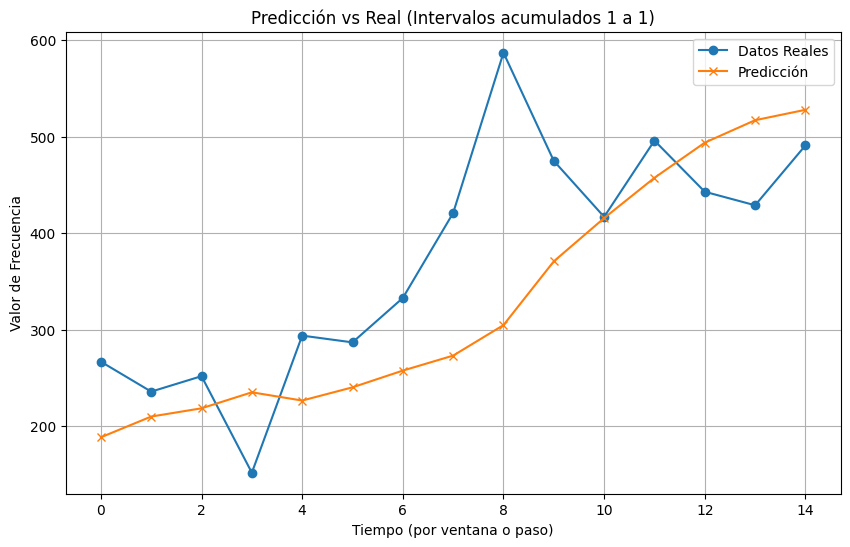

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
Acumulando intervalos 1 a 2: MAE = 131.36, MSE = 28039.37


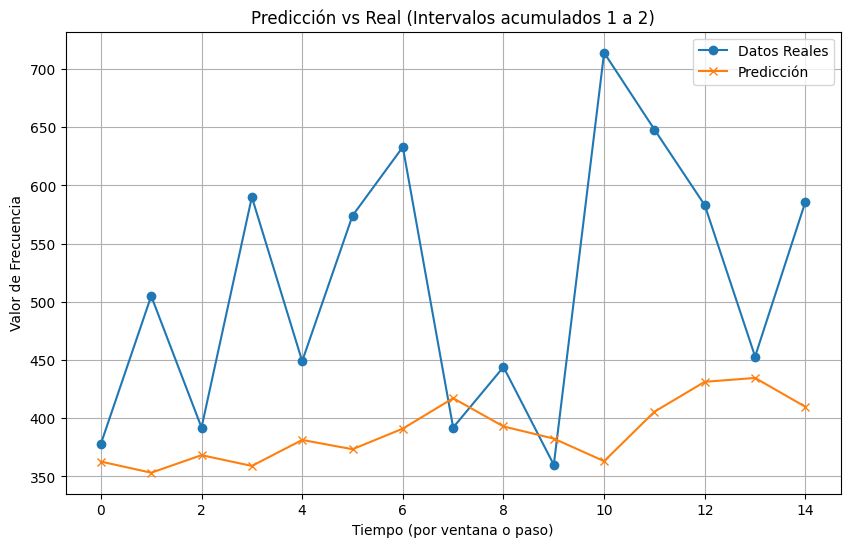

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Acumulando intervalos 1 a 3: MAE = 298.08, MSE = 130552.67


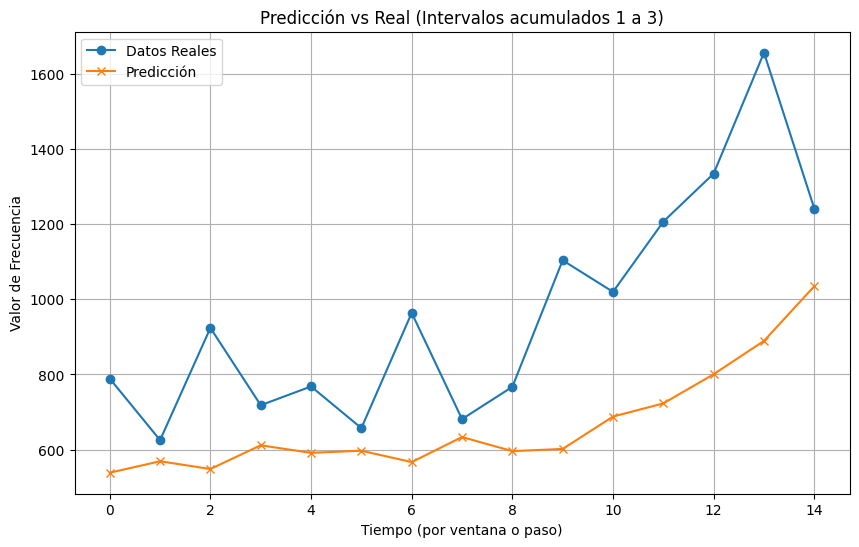

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
Acumulando intervalos 1 a 4: MAE = 143.79, MSE = 20715.52


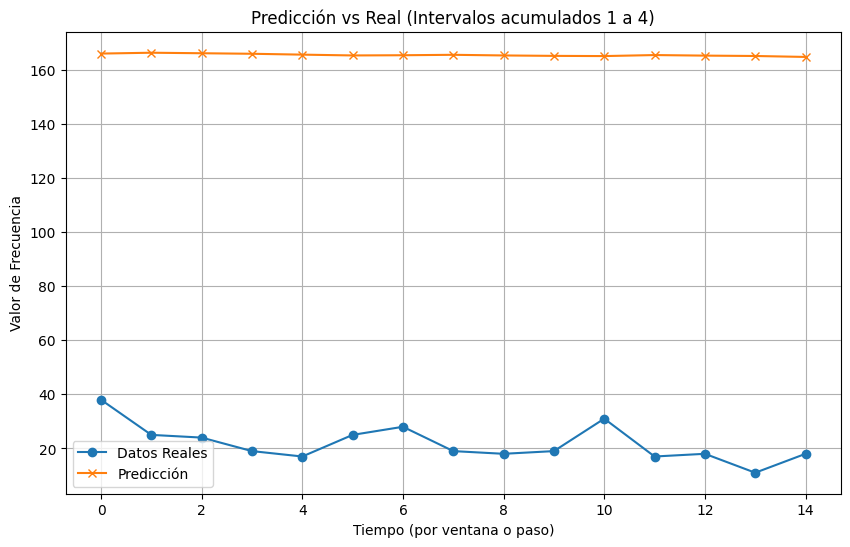

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
Acumulando intervalos 1 a 5: MAE = 80.39, MSE = 7895.57


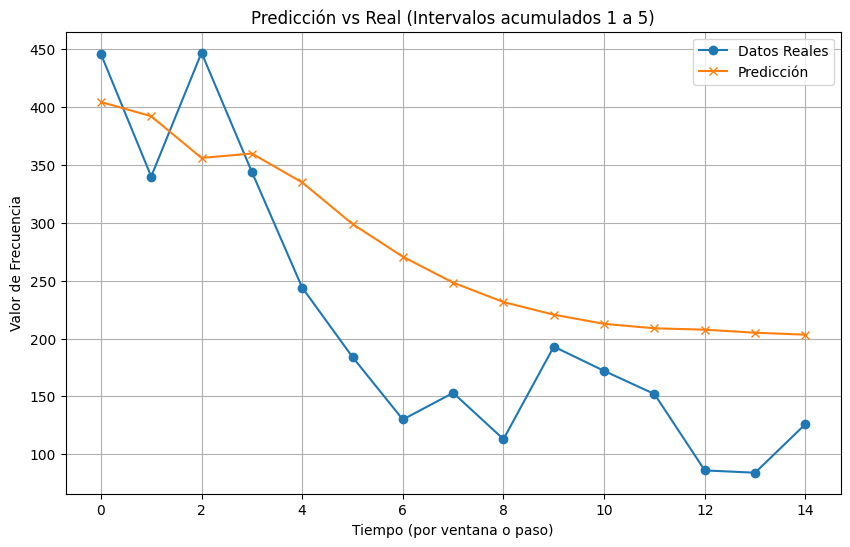

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
Acumulando intervalos 1 a 6: MAE = 18.62, MSE = 517.17


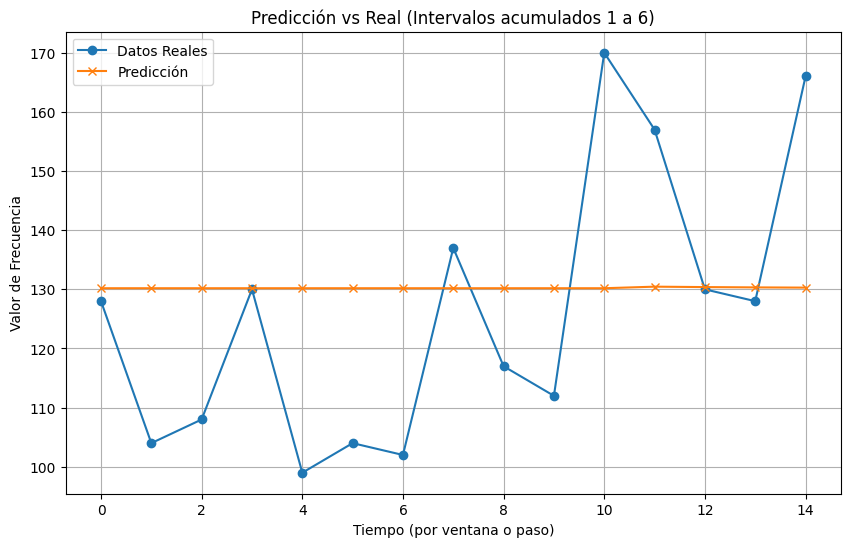

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
Acumulando intervalos 1 a 7: MAE = 84.46, MSE = 7564.60


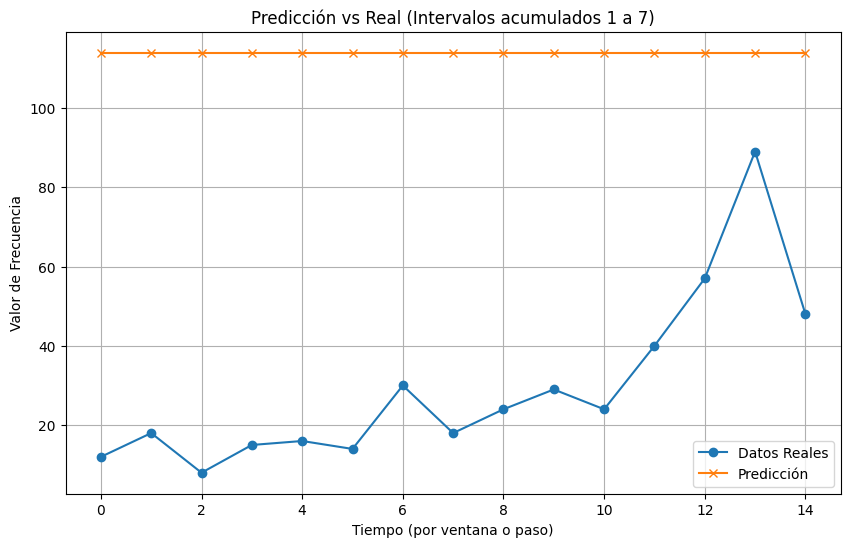

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
Acumulando intervalos 1 a 8: MAE = 111.23, MSE = 12378.72


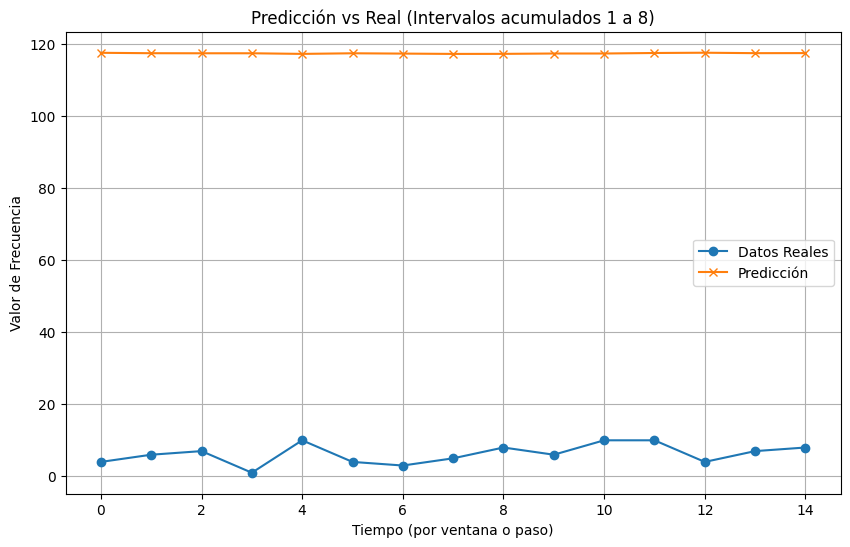


Resumen de métricas:
  Intervalos Acumulados         MAE            MSE       SMAPE
0      Intervalos 1 a 1   77.283665   10174.424016   23.170866
1      Intervalos 1 a 2  131.356047   28039.372811   27.028175
2      Intervalos 1 a 3  298.077942  130552.670493   34.056317
3      Intervalos 1 a 4  143.786820   20715.516136  153.892002
4      Intervalos 1 a 5   80.394410    7895.571327   39.748817
5      Intervalos 1 a 6   18.618787     517.172632   14.578691
6      Intervalos 1 a 7   84.456399    7564.598806  123.453644
7      Intervalos 1 a 8  111.227835   12378.720147  180.111977


In [13]:
# Parameters
WINDOW_SIZE = 7
HORIZONTE = 15 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    model = build_lstm_model(WINDOW_SIZE)
    history = model.fit(x_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_2/lstm_7_15.csv', index=False)

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Acumulando intervalos 1 a 1: MAE = 83.23, MSE = 11229.32


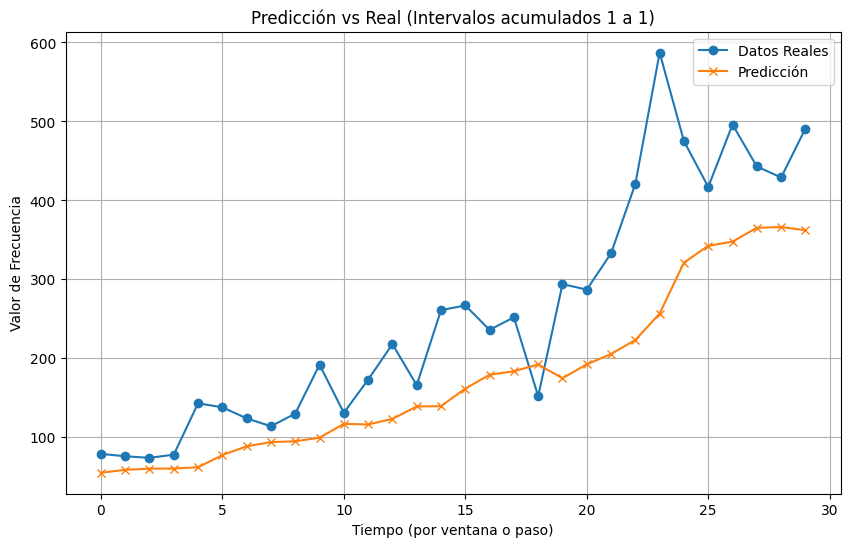

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Acumulando intervalos 1 a 2: MAE = 91.99, MSE = 14538.67


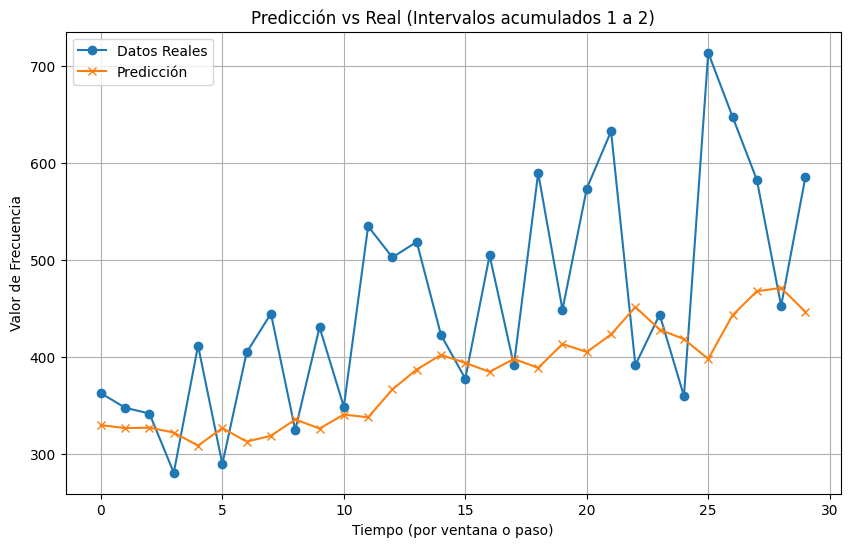

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
Acumulando intervalos 1 a 3: MAE = 230.67, MSE = 86147.64


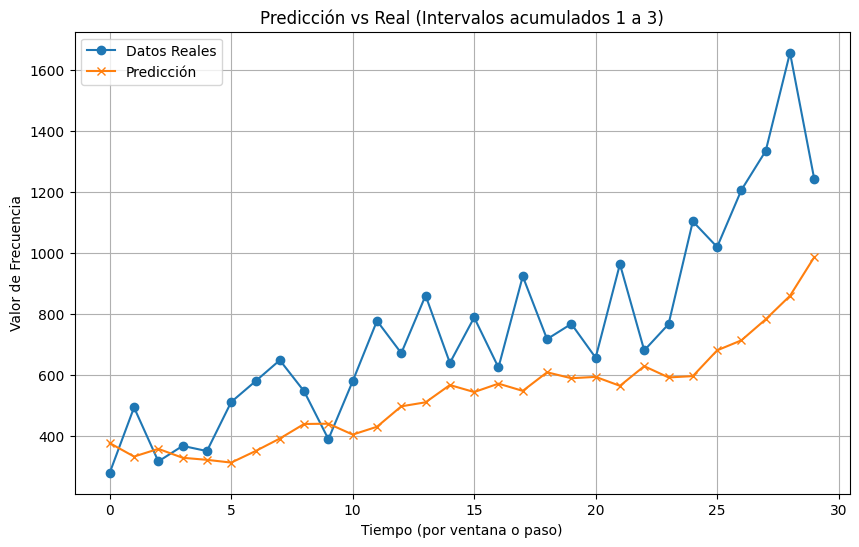

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Acumulando intervalos 1 a 4: MAE = 177.45, MSE = 31529.21


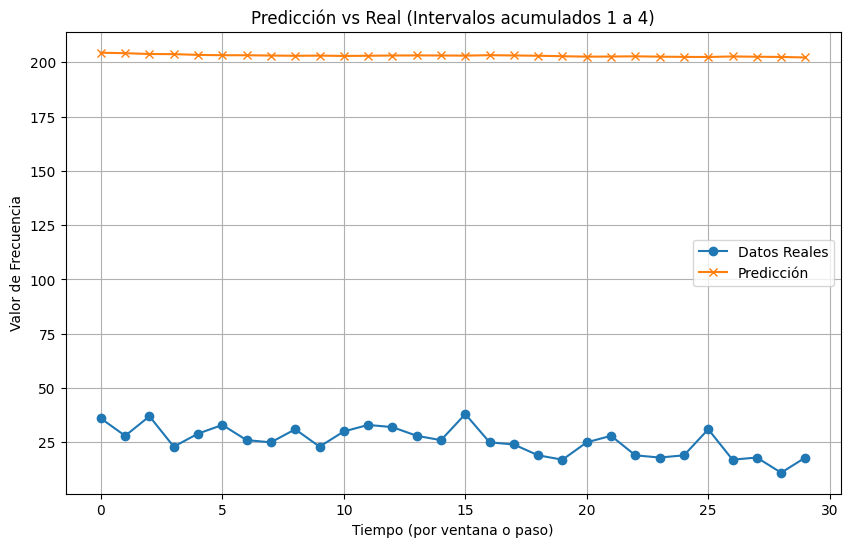

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
Acumulando intervalos 1 a 5: MAE = 86.40, MSE = 14520.22


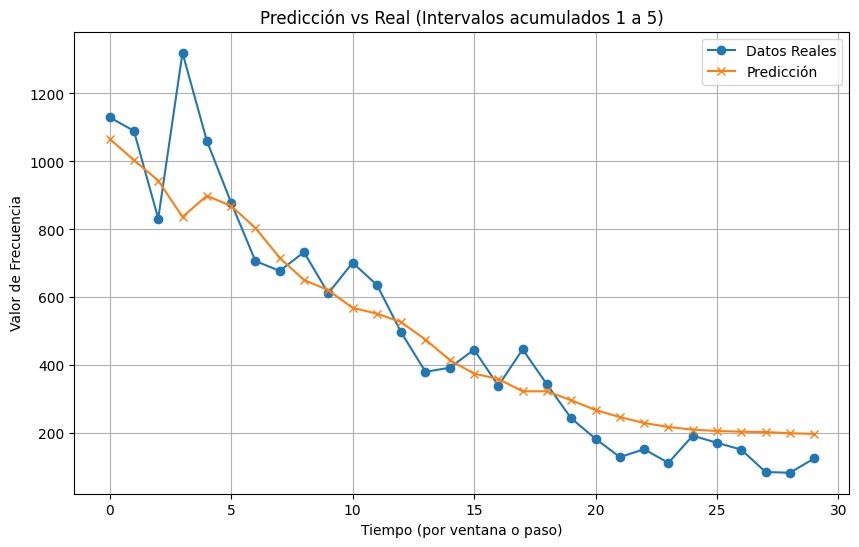

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
Acumulando intervalos 1 a 6: MAE = 29.64, MSE = 1086.83


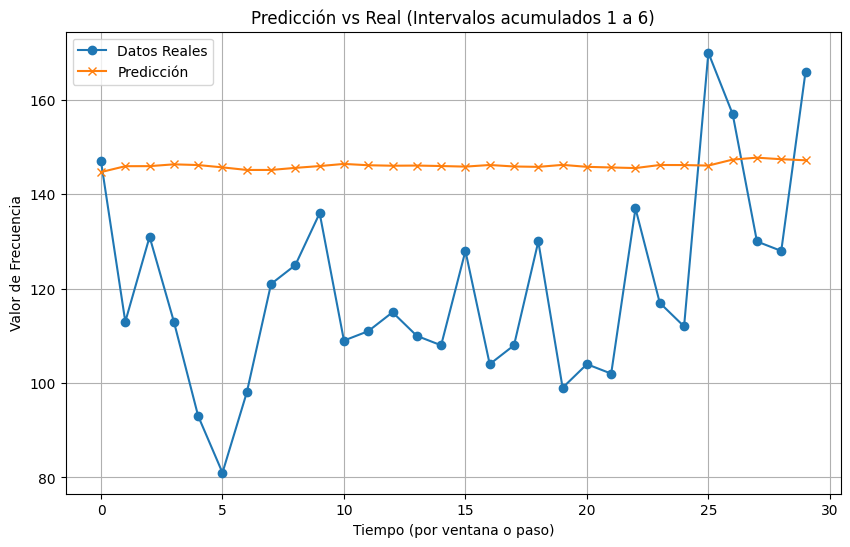

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Acumulando intervalos 1 a 7: MAE = 112.23, MSE = 16082.63


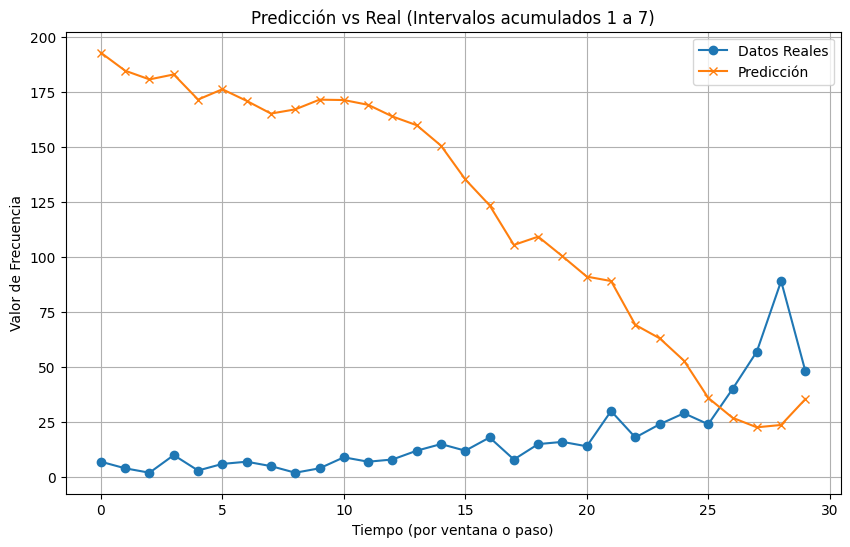

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
Acumulando intervalos 1 a 8: MAE = 112.80, MSE = 12731.59


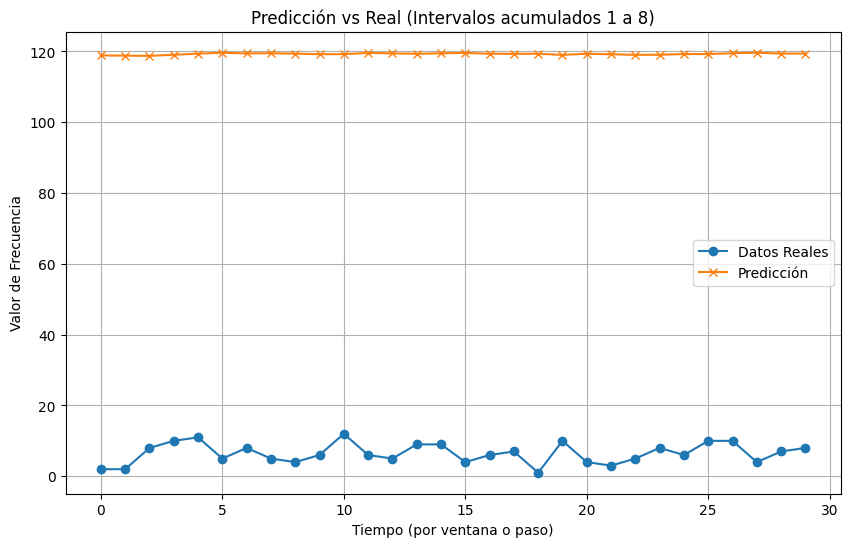


Resumen de métricas:
  Intervalos Acumulados         MAE           MSE       SMAPE
0      Intervalos 1 a 1   83.225033  11229.324129   38.034997
1      Intervalos 1 a 2   91.994607  14538.669681   20.415482
2      Intervalos 1 a 3  230.665118  86147.639541   33.035390
3      Intervalos 1 a 4  177.449346  31529.208622  155.574174
4      Intervalos 1 a 5   86.403388  14520.220918   24.604102
5      Intervalos 1 a 6   29.637075   1086.827334   23.112911
6      Intervalos 1 a 7  112.230887  16082.634564  145.984040
7      Intervalos 1 a 8  112.798779  12731.590121  179.523861


In [14]:
# Parameters
WINDOW_SIZE = 7 
HORIZONTE = 30 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    model = build_lstm_model(WINDOW_SIZE)
    history = model.fit(x_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_2/lstm_7_30.csv', index=False)

### Train for windows size = 14

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Acumulando intervalos 1 a 1: MAE = 69.14, MSE = 8047.38


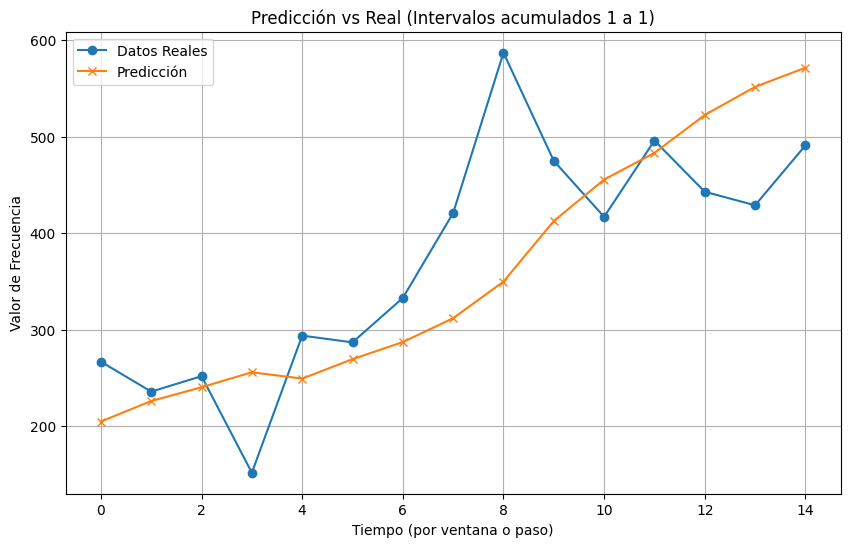

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
Acumulando intervalos 1 a 2: MAE = 130.05, MSE = 27720.14


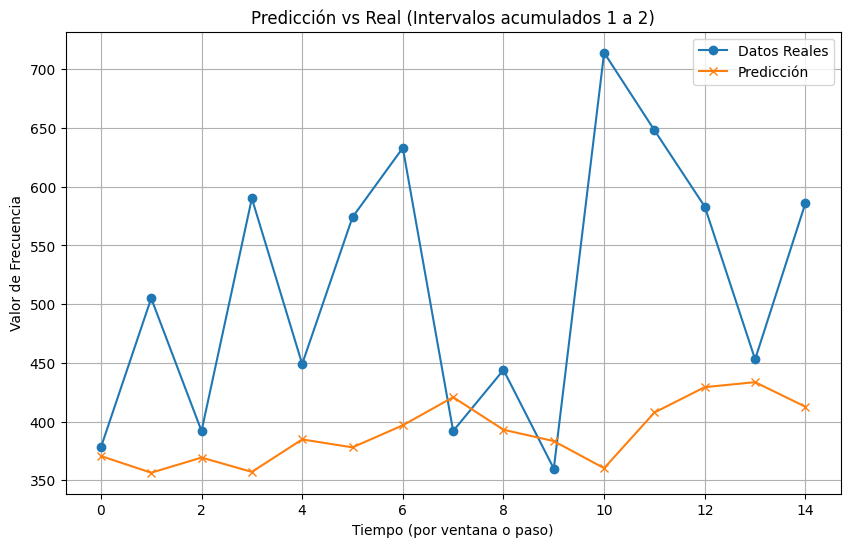

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Acumulando intervalos 1 a 3: MAE = 277.46, MSE = 117808.56


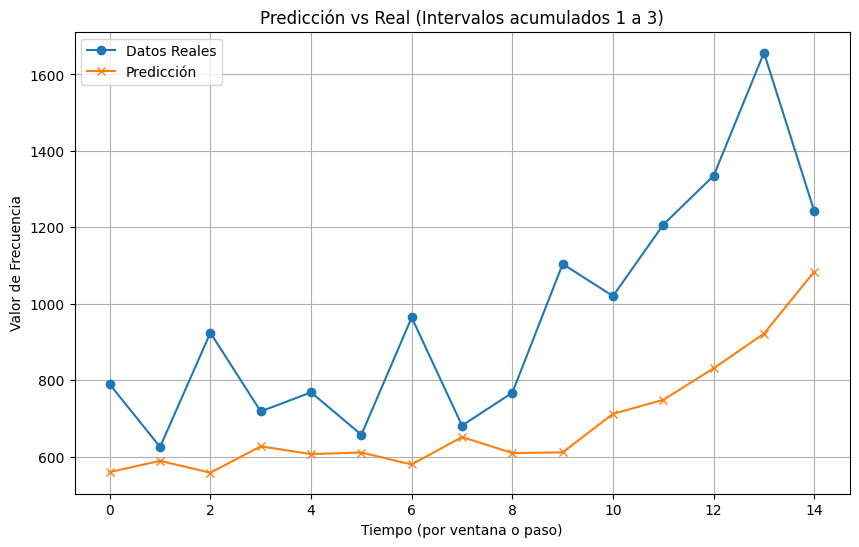

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
Acumulando intervalos 1 a 4: MAE = 84.88, MSE = 7568.98


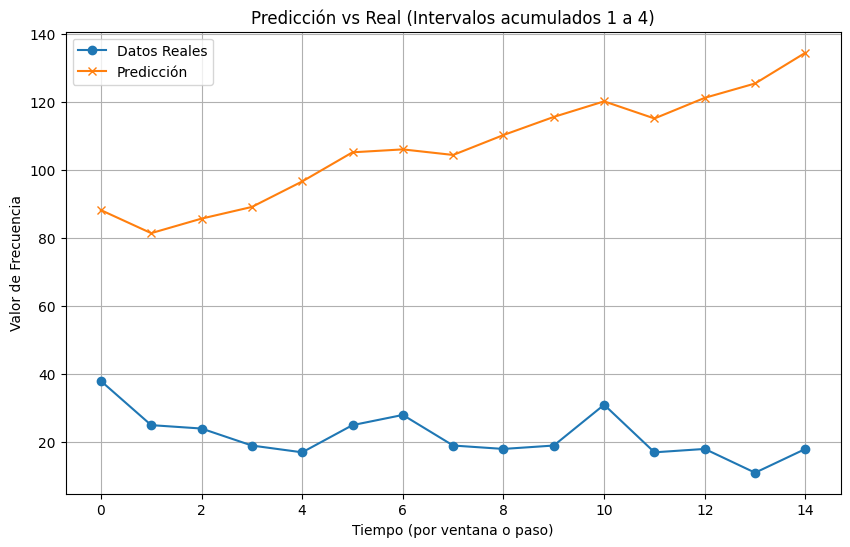

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
Acumulando intervalos 1 a 5: MAE = 62.95, MSE = 5564.39


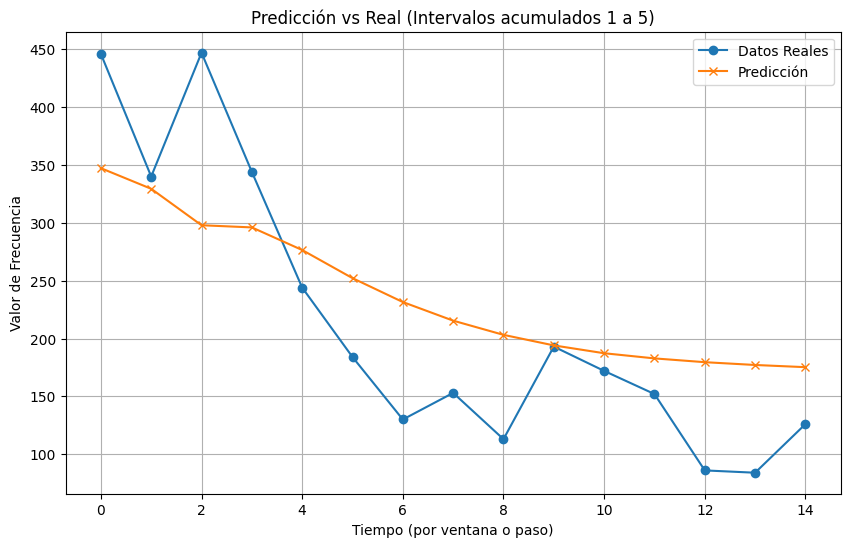

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
Acumulando intervalos 1 a 6: MAE = 98.39, MSE = 10100.62


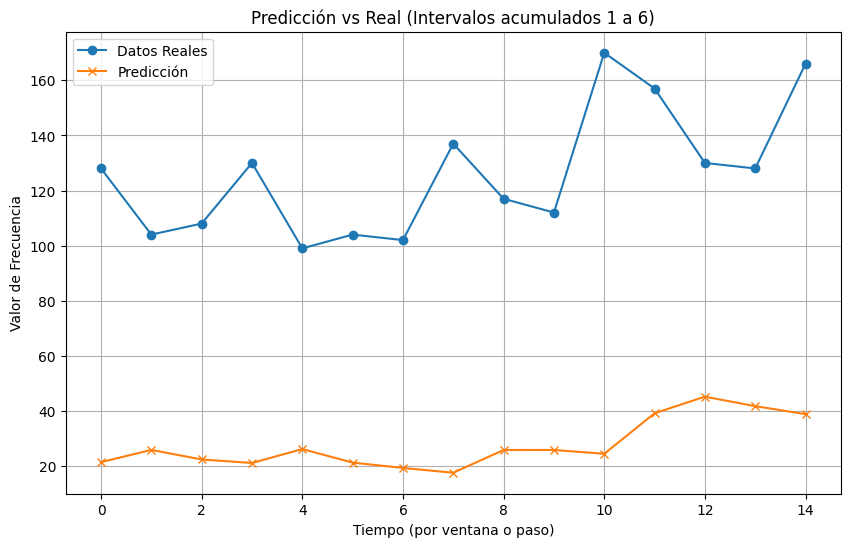

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Acumulando intervalos 1 a 7: MAE = 79.74, MSE = 6783.44


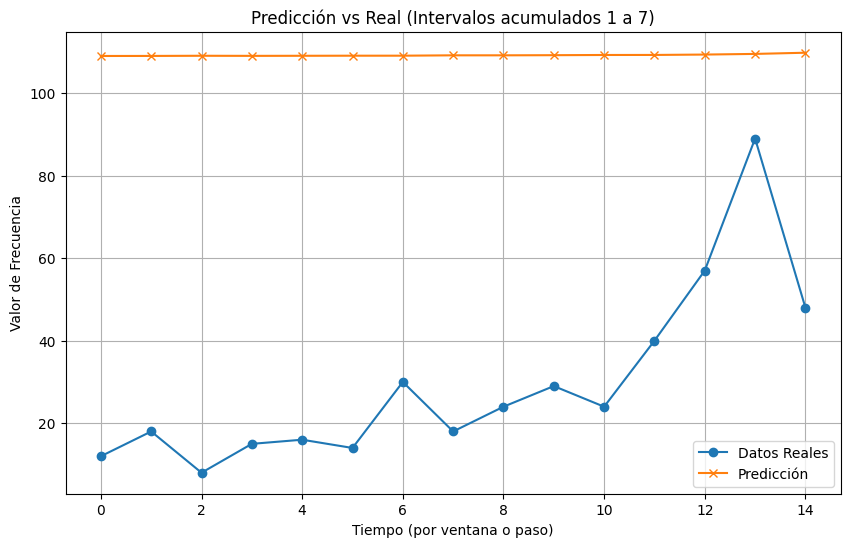

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
Acumulando intervalos 1 a 8: MAE = 111.79, MSE = 12503.79


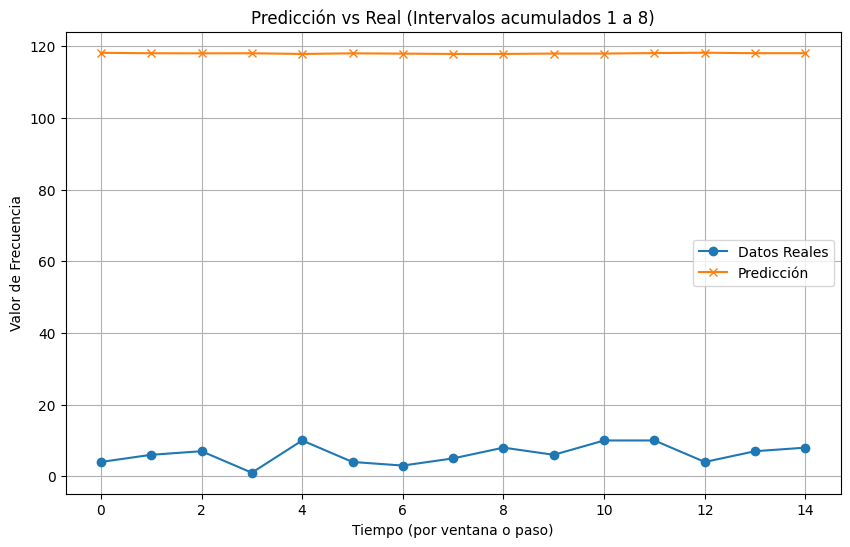


Resumen de métricas:
  Intervalos Acumulados         MAE            MSE       SMAPE
0      Intervalos 1 a 1   69.141349    8047.379239   19.063004
1      Intervalos 1 a 2  130.047272   27720.141009   26.682130
2      Intervalos 1 a 3  277.460832  117808.560531   31.230675
3      Intervalos 1 a 4   84.880985    7568.983824  131.290342
4      Intervalos 1 a 5   62.948807    5564.391624   31.721991
5      Intervalos 1 a 6   98.389887   10100.617163  128.192631
6      Intervalos 1 a 7   79.738624    6783.443470  121.003180
7      Intervalos 1 a 8  111.788497   12503.785820  180.200692


In [15]:
# Parameters
WINDOW_SIZE = 14 
HORIZONTE = 15 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    model = build_lstm_model(WINDOW_SIZE)
    history = model.fit(x_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_2/lstm_14_15.csv', index=False)

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
Acumulando intervalos 1 a 1: MAE = 88.70, MSE = 13061.47


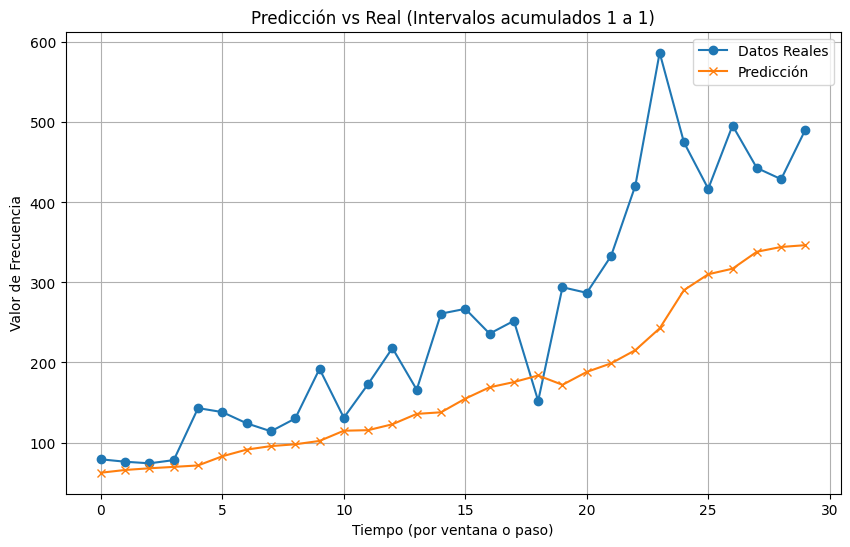

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
Acumulando intervalos 1 a 2: MAE = 111.44, MSE = 20527.90


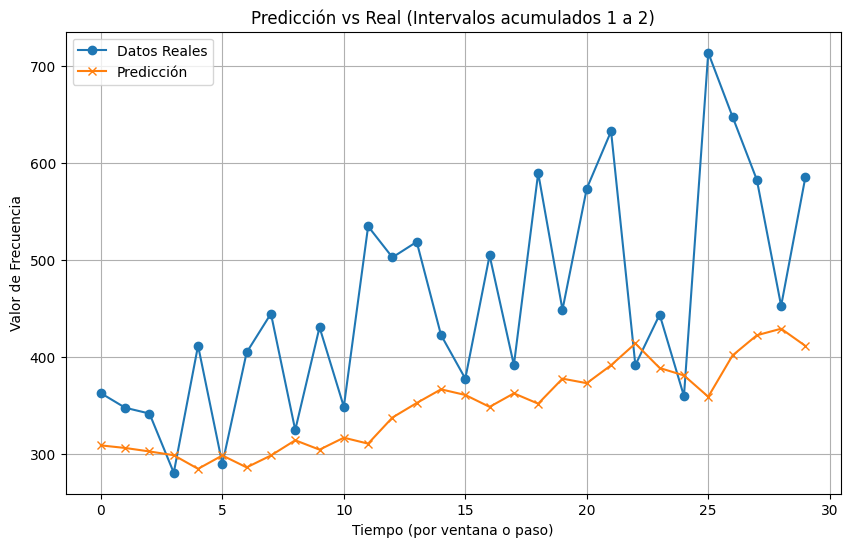

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
Acumulando intervalos 1 a 3: MAE = 239.69, MSE = 90914.78


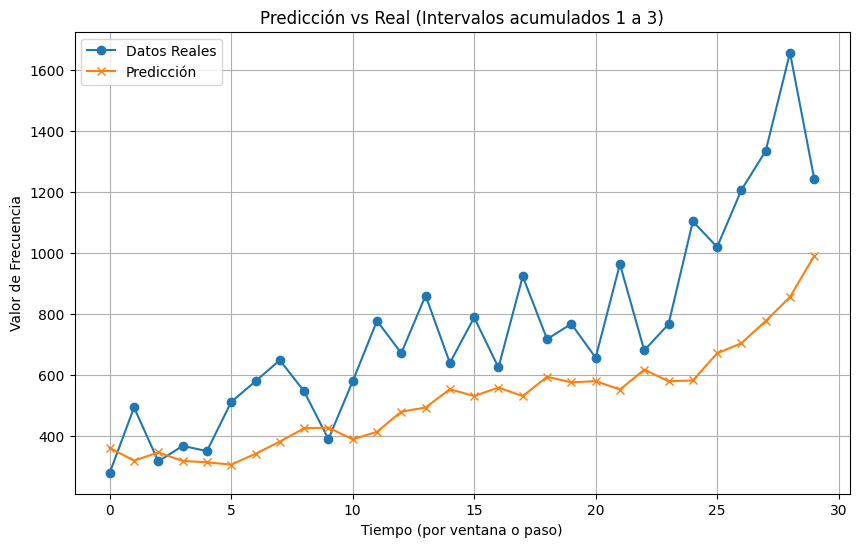

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
Acumulando intervalos 1 a 4: MAE = 106.91, MSE = 12263.31


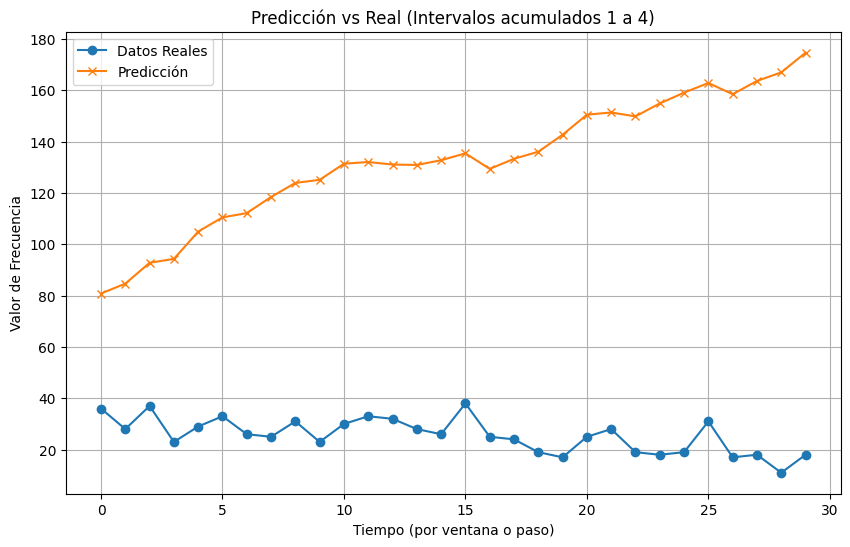

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Acumulando intervalos 1 a 5: MAE = 85.87, MSE = 13334.85


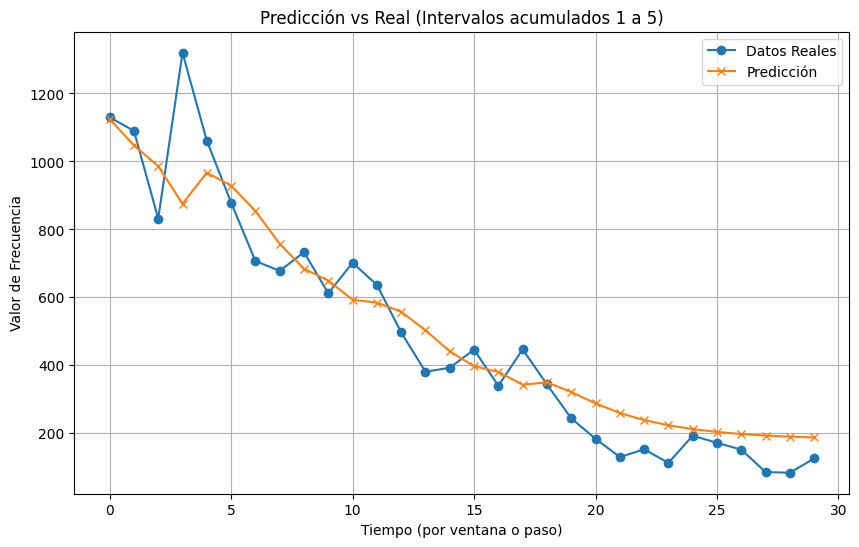

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Acumulando intervalos 1 a 6: MAE = 29.94, MSE = 1109.37


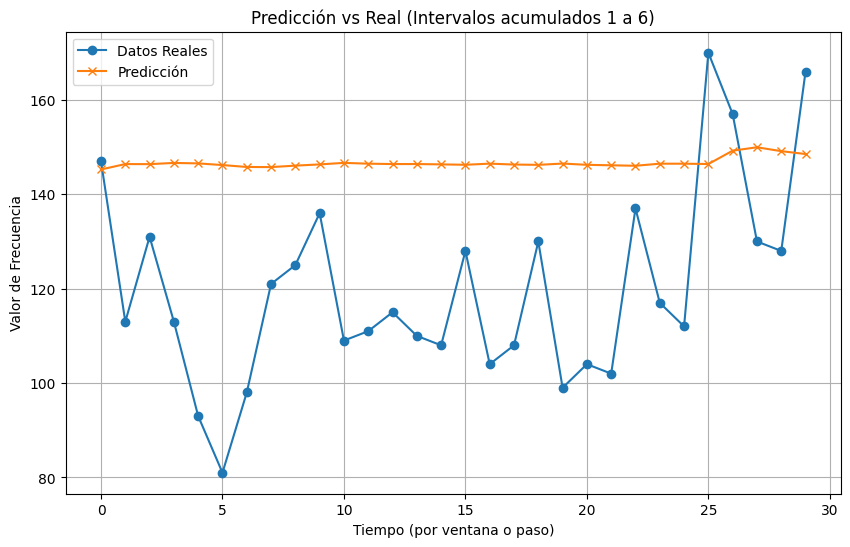

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Acumulando intervalos 1 a 7: MAE = 51.22, MSE = 3903.47


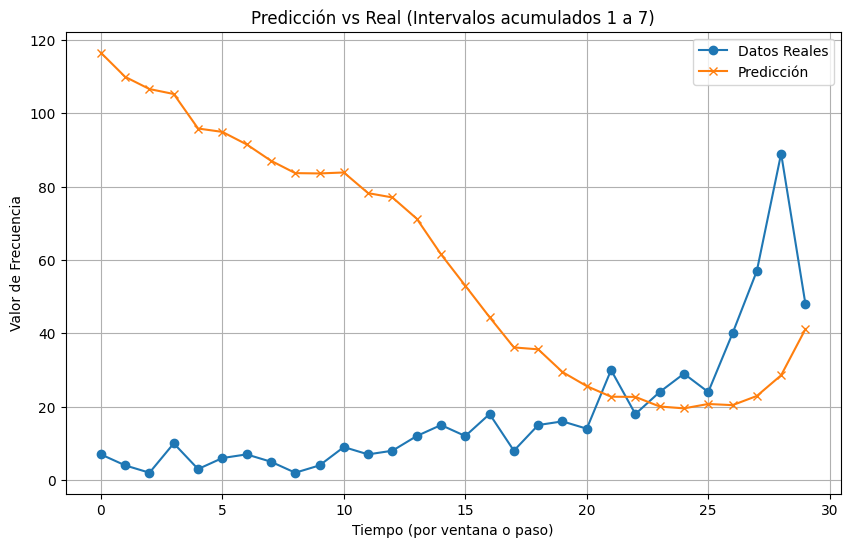

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Acumulando intervalos 1 a 8: MAE = 111.65, MSE = 12474.59


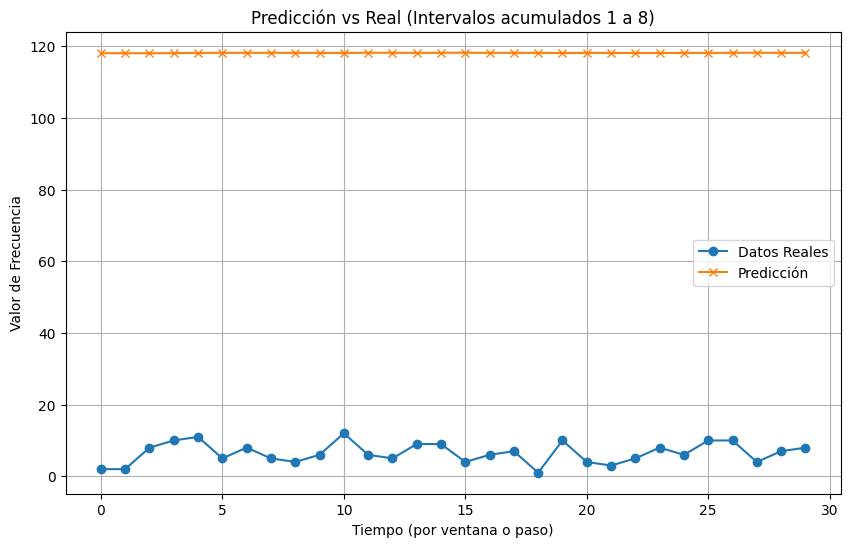


Resumen de métricas:
  Intervalos Acumulados         MAE           MSE       SMAPE
0      Intervalos 1 a 1   88.696540  13061.465434   38.053847
1      Intervalos 1 a 2  111.437475  20527.900037   25.576273
2      Intervalos 1 a 3  239.693384  90914.781824   34.756732
3      Intervalos 1 a 4  106.907996  12263.313988  133.059036
4      Intervalos 1 a 5   85.870367  13334.850510   24.686847
5      Intervalos 1 a 6   29.943649   1109.373935   23.317390
6      Intervalos 1 a 7   51.220999   3903.468600  116.337754
7      Intervalos 1 a 8  111.653932  12474.586451  179.337247


In [16]:
# Parameters
WINDOW_SIZE = 14 
HORIZONTE = 30 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    model = build_lstm_model(WINDOW_SIZE)
    history = model.fit(x_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_2/lstm_14_30.csv', index=False)

### Train for windows size = 21


c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
Acumulando intervalos 1 a 1: MAE = 68.36, MSE = 7845.97


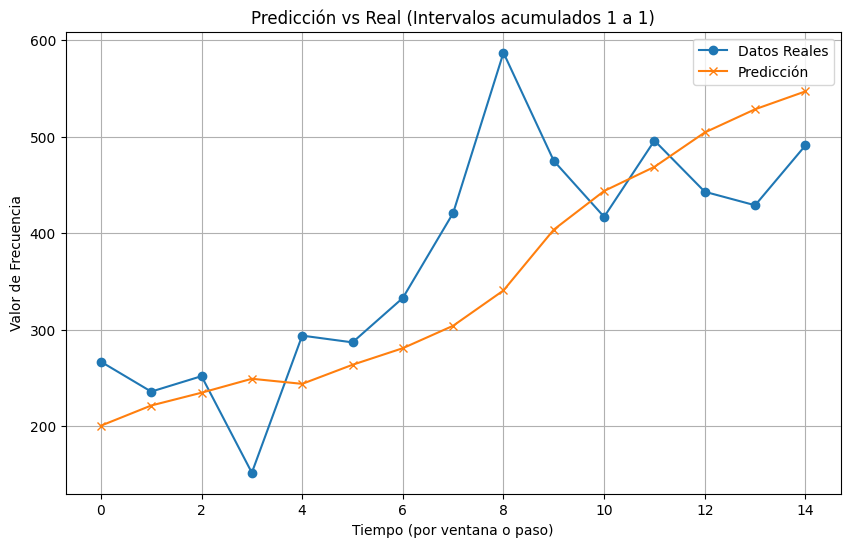

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
Acumulando intervalos 1 a 2: MAE = 131.24, MSE = 27949.43


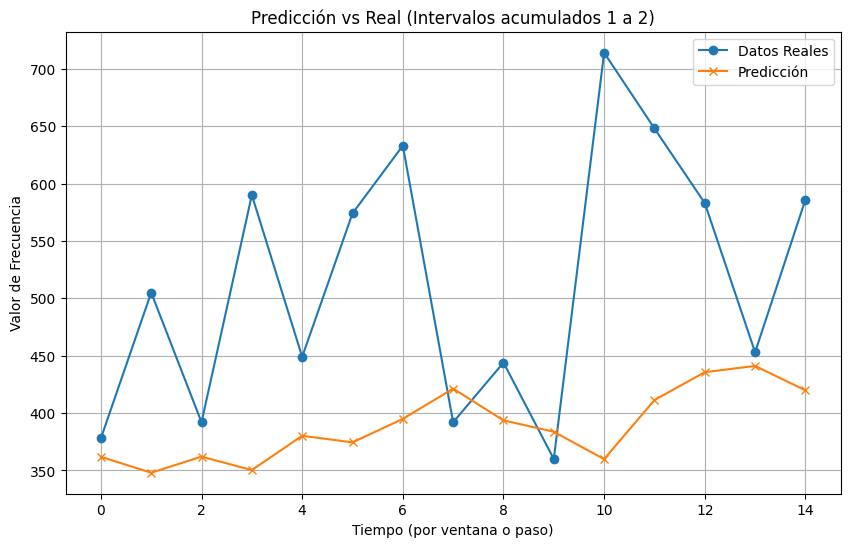

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
Acumulando intervalos 1 a 3: MAE = 307.13, MSE = 137357.07


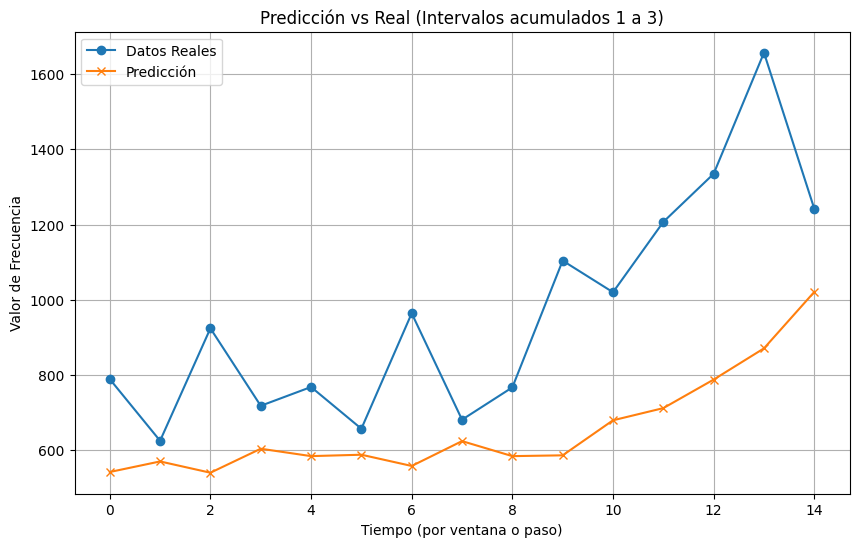

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Acumulando intervalos 1 a 4: MAE = 139.36, MSE = 19832.99


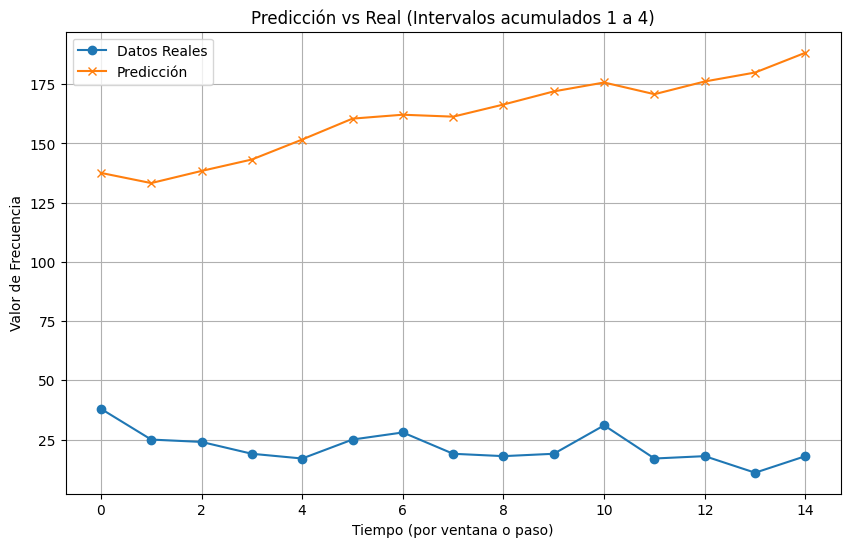

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Acumulando intervalos 1 a 5: MAE = 50.38, MSE = 4181.19


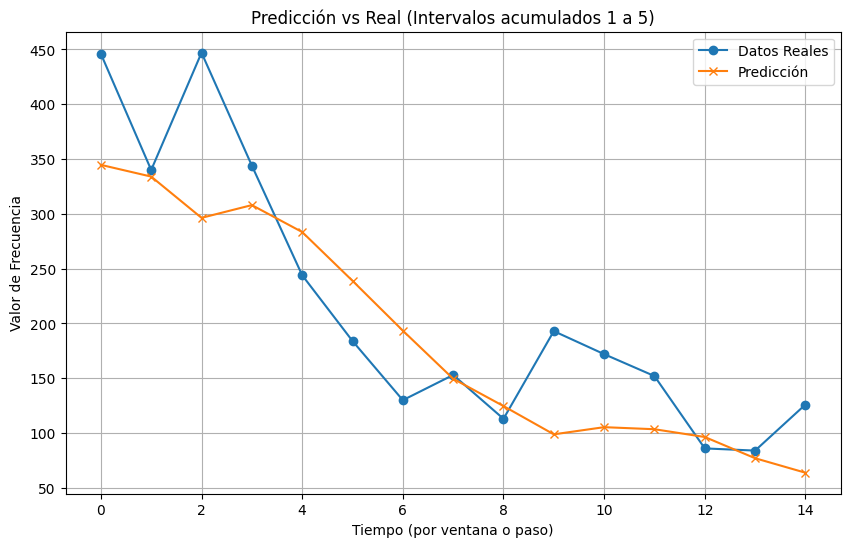

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
Acumulando intervalos 1 a 6: MAE = 16.82, MSE = 625.41


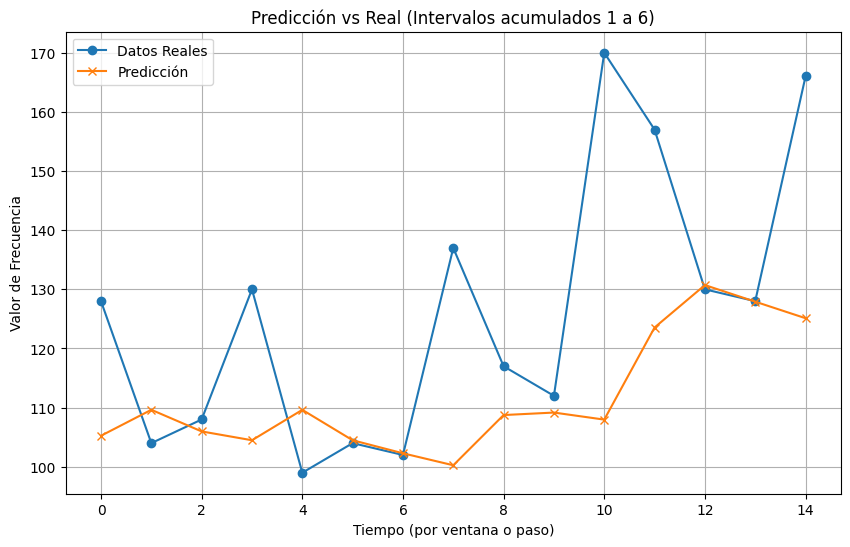

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Acumulando intervalos 1 a 7: MAE = 84.28, MSE = 7524.56


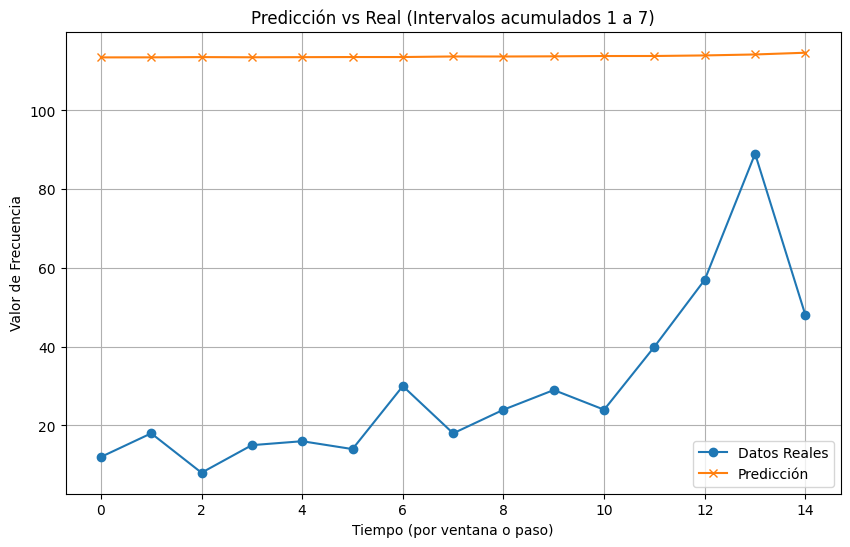

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
Acumulando intervalos 1 a 8: MAE = 98.89, MSE = 9786.55


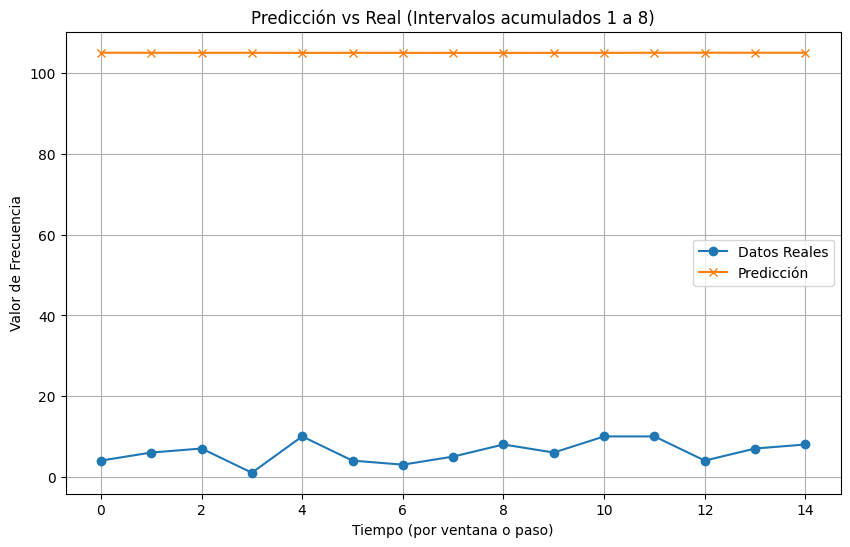


Resumen de métricas:
  Intervalos Acumulados         MAE            MSE       SMAPE
0      Intervalos 1 a 1   68.356025    7845.968545   19.465892
1      Intervalos 1 a 2  131.236584   27949.434073   27.060364
2      Intervalos 1 a 3  307.129333  137357.070275   35.316797
3      Intervalos 1 a 4  139.362389   19832.994543  151.930155
4      Intervalos 1 a 5   50.379153    4181.185516   27.154540
5      Intervalos 1 a 6   16.820161     625.408081   13.158913
6      Intervalos 1 a 7   84.276546    7524.557350  123.406335
7      Intervalos 1 a 8   98.891735    9786.554319  177.929006


In [17]:
# Parameters
WINDOW_SIZE = 21 
HORIZONTE = 15 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    model = build_lstm_model(WINDOW_SIZE)
    history = model.fit(x_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_2/lstm_21_15.csv', index=False)

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
Acumulando intervalos 1 a 1: MAE = 78.88, MSE = 10514.95


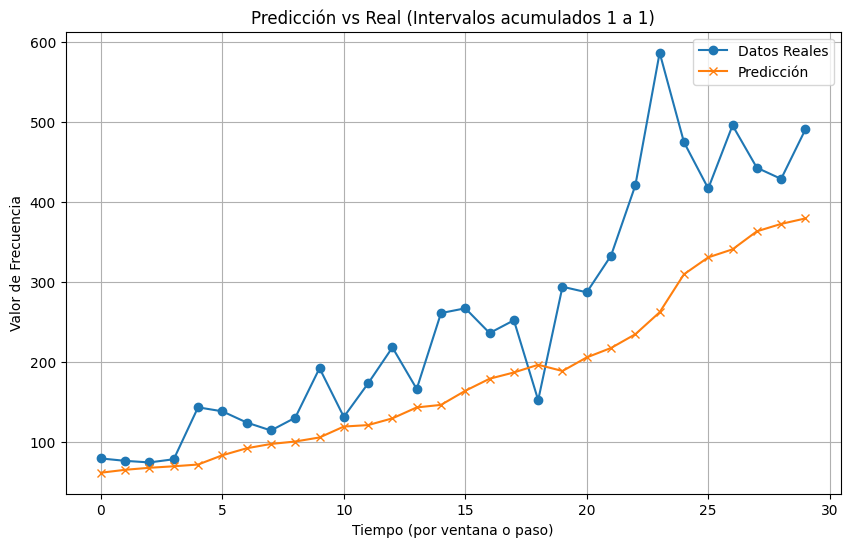

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
Acumulando intervalos 1 a 2: MAE = 104.59, MSE = 18687.96


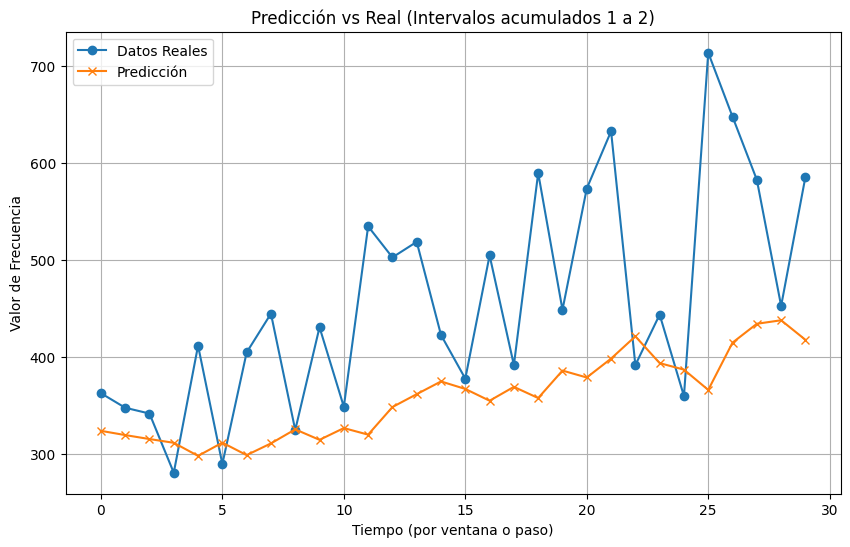

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
Acumulando intervalos 1 a 3: MAE = 229.89, MSE = 84632.63


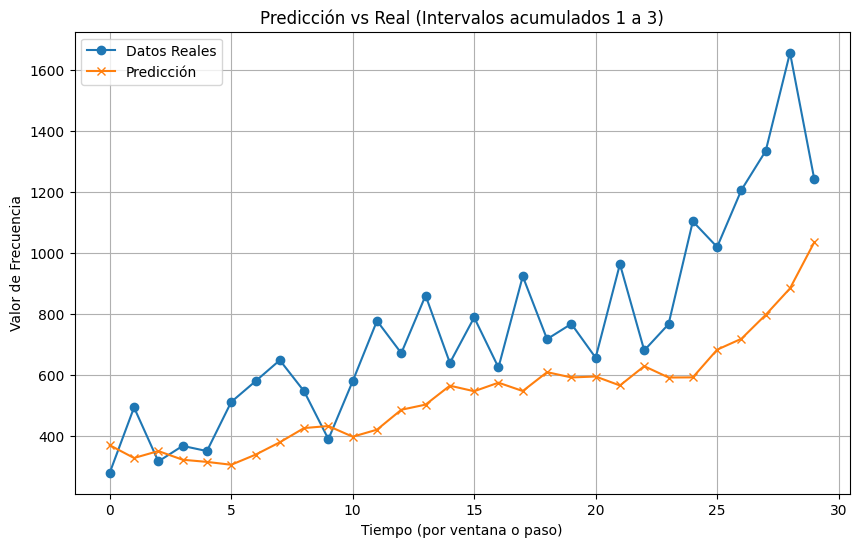

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
Acumulando intervalos 1 a 4: MAE = 188.17, MSE = 36361.91


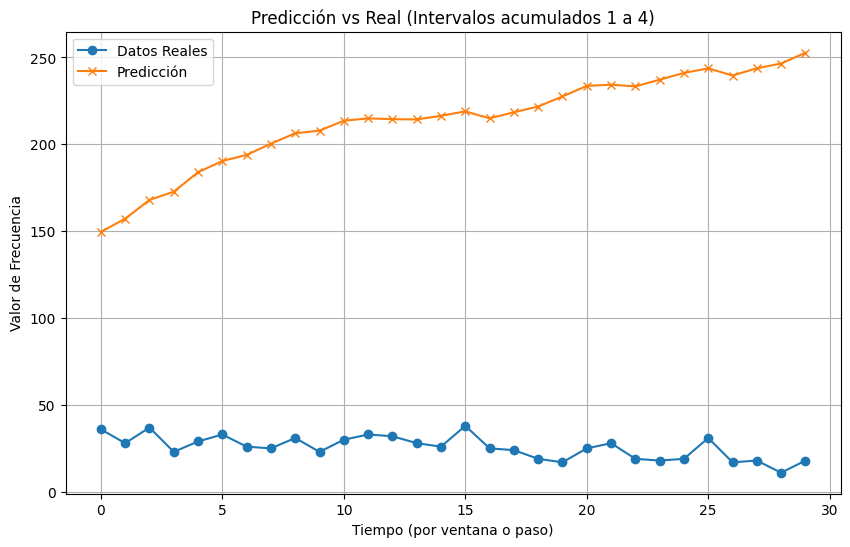

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
Acumulando intervalos 1 a 5: MAE = 94.50, MSE = 19418.51


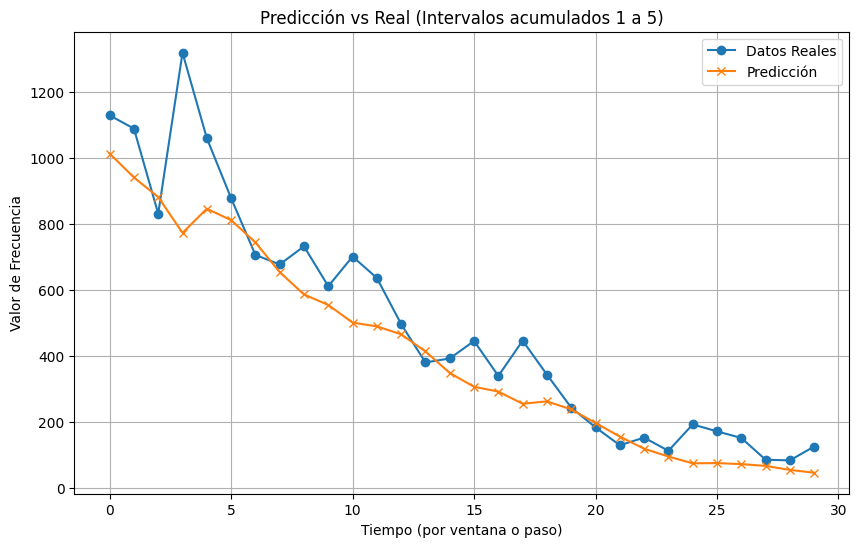

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
Acumulando intervalos 1 a 6: MAE = 30.29, MSE = 1134.50


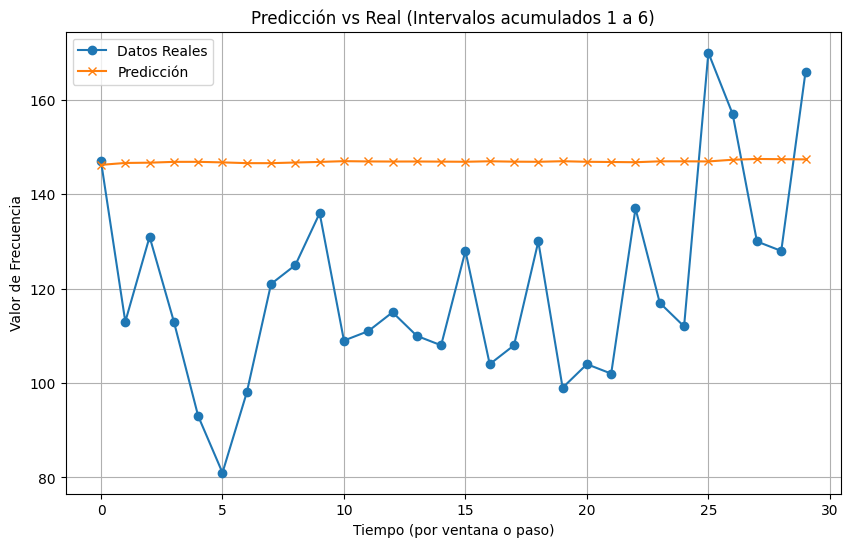

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
Acumulando intervalos 1 a 7: MAE = 40.90, MSE = 2598.78


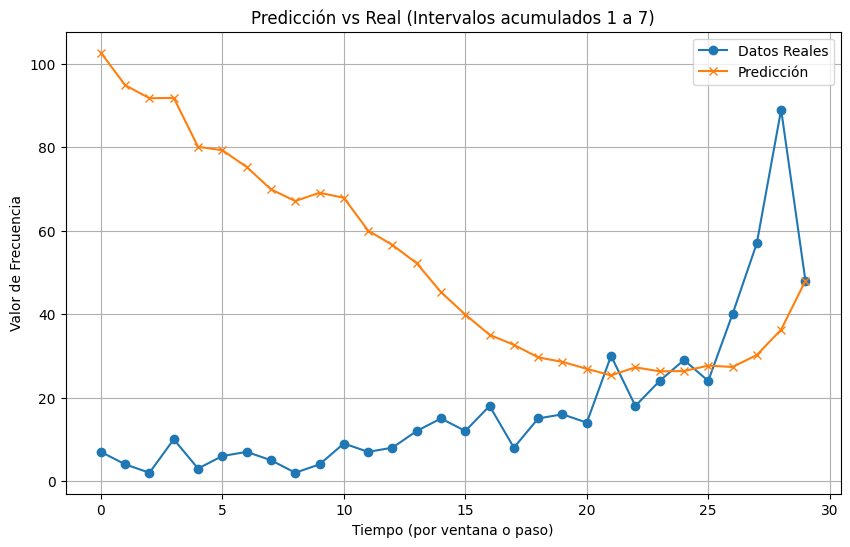

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
Acumulando intervalos 1 a 8: MAE = 87.12, MSE = 7850.66


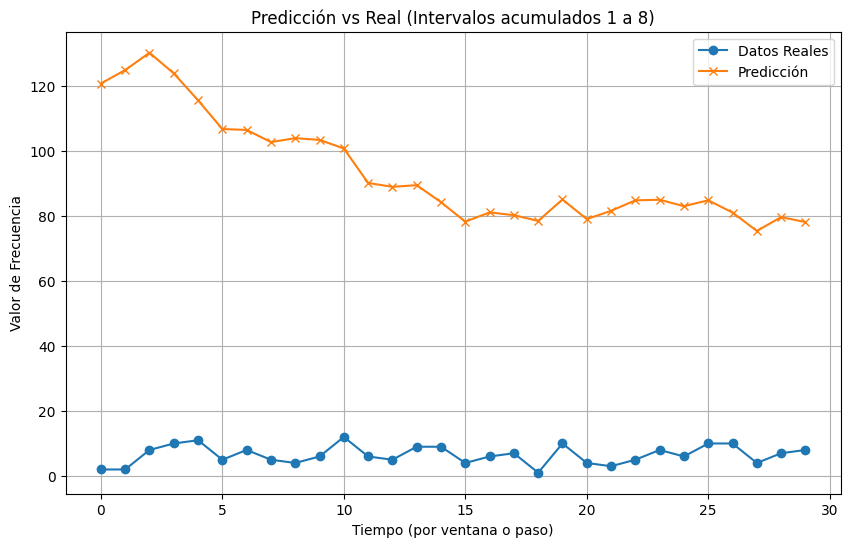


Resumen de métricas:
  Intervalos Acumulados         MAE           MSE       SMAPE
0      Intervalos 1 a 1   78.881080  10514.952911   34.073417
1      Intervalos 1 a 2  104.586197  18687.961040   23.644533
2      Intervalos 1 a 3  229.886339  84632.632052   33.294939
3      Intervalos 1 a 4  188.166839  36361.913009  156.346171
4      Intervalos 1 a 5   94.504731  19418.505315   27.887342
5      Intervalos 1 a 6   30.288503   1134.501774   23.547239
6      Intervalos 1 a 7   40.897455   2598.782524  107.096999
7      Intervalos 1 a 8   87.116213   7850.659618  173.845222


In [18]:
# Parameters
WINDOW_SIZE = 21 
HORIZONTE = 30
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    model = build_lstm_model(WINDOW_SIZE)
    history = model.fit(x_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_2/lstm_21_30.csv', index=False)

## TimesFM

In [24]:
import pandas as pd
import timesfm
import os
from huggingface_hub import login
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from dotenv import load_dotenv


load_dotenv()
hf_token = os.getenv("HUGGINGFACE_API_KEY")
# Log in with the token
login(token=hf_token)


Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 5117.50it/s]


Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 1: MAE = 161.83, MSE = 39464.28


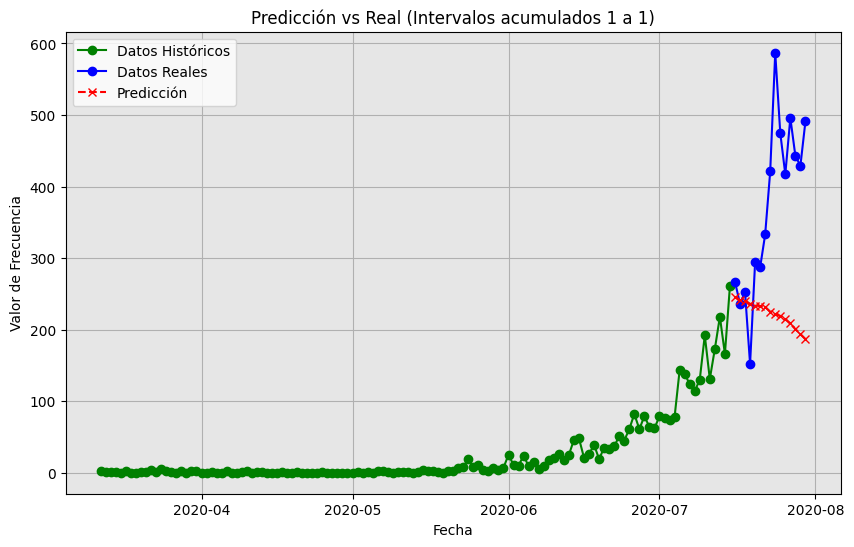

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 2: MAE = 182.36, MSE = 49539.47


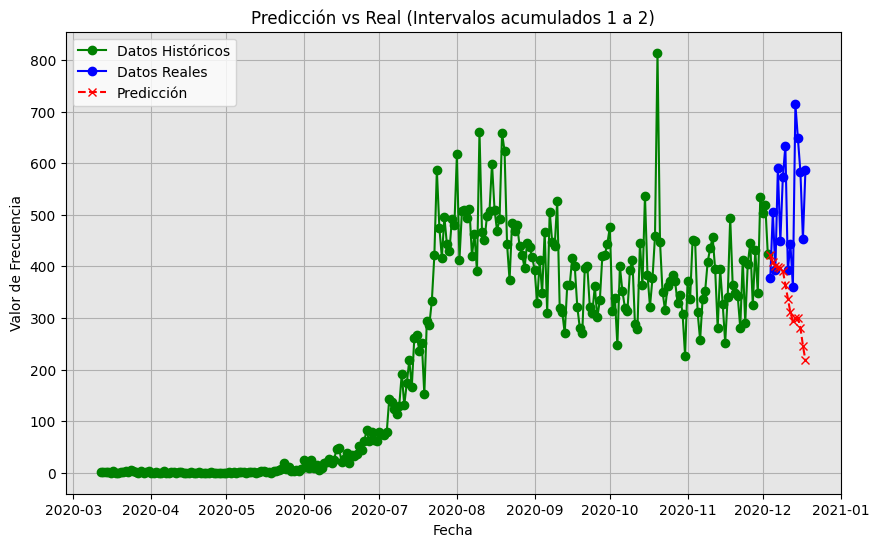

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 3: MAE = 325.83, MSE = 181618.79


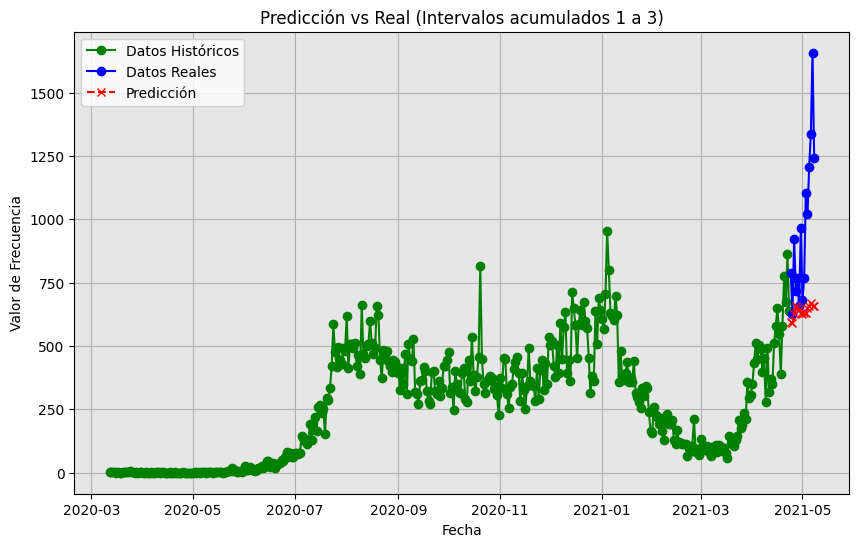

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 4: MAE = 24.57, MSE = 638.38


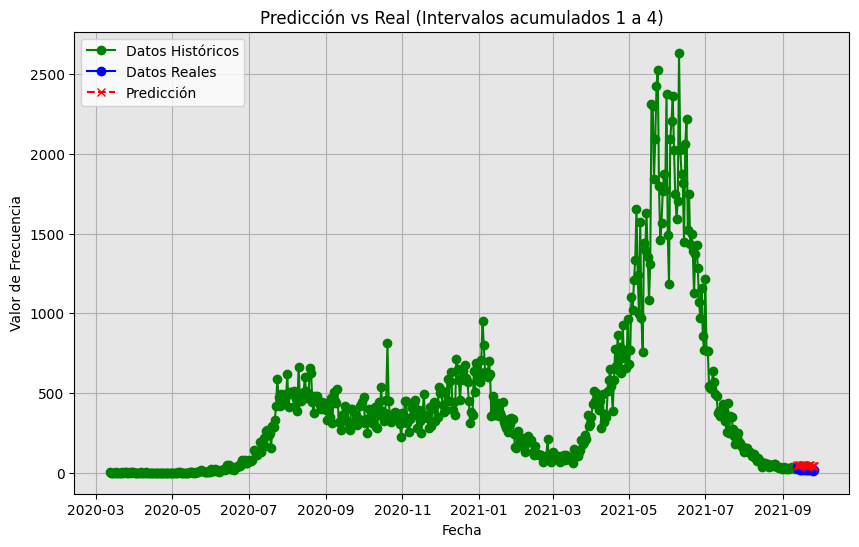

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 5: MAE = 71.05, MSE = 10091.89


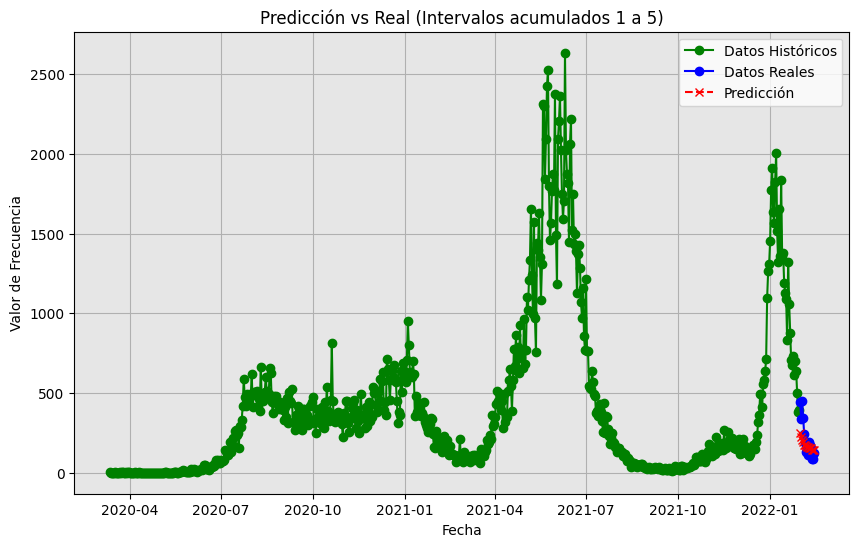

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 6: MAE = 147.89, MSE = 22724.88


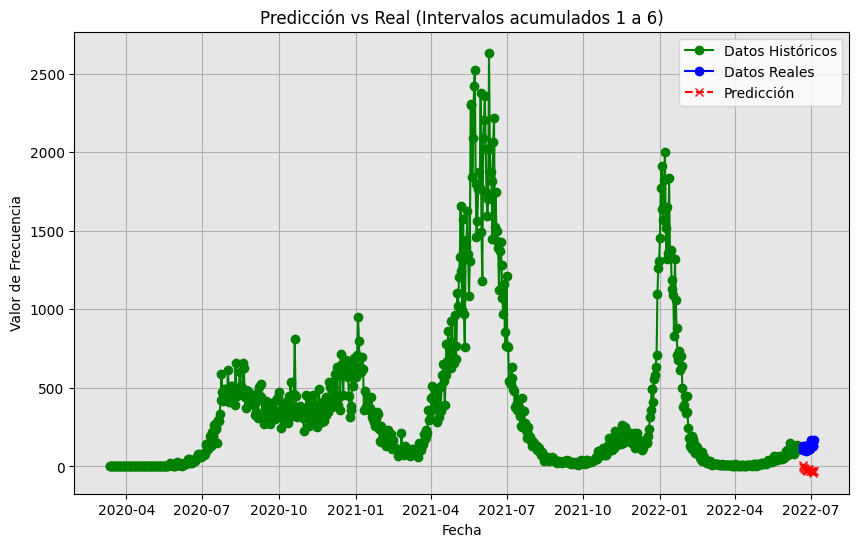

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 7: MAE = 333.50, MSE = 145953.74


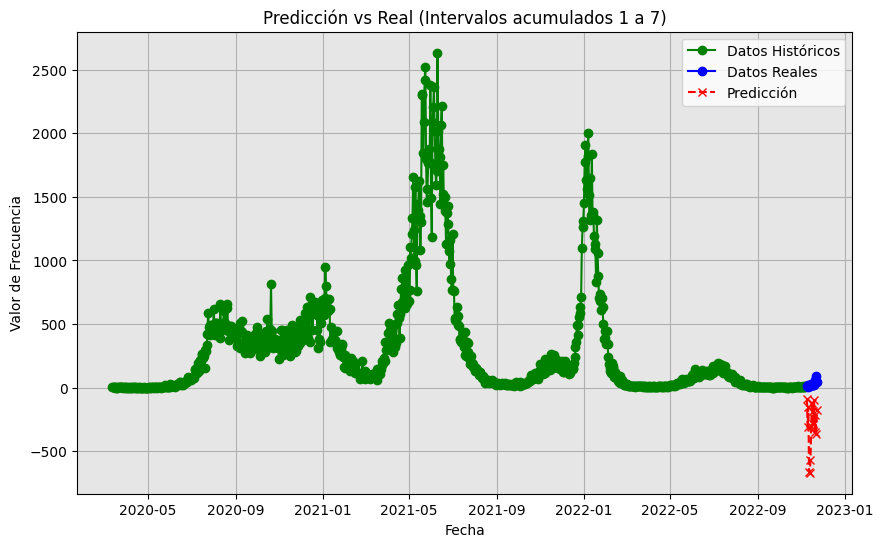

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 8: MAE = 42.47, MSE = 1823.03


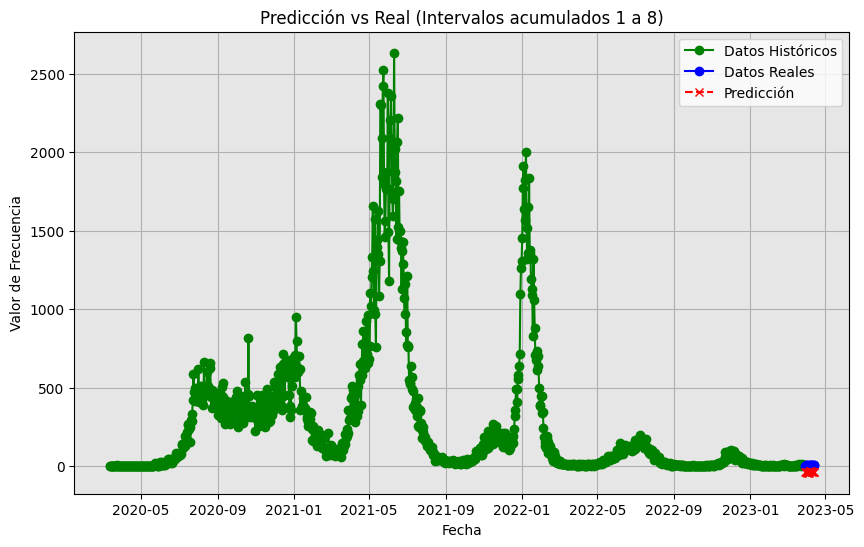


Resumen de métricas:
  Intervalos Acumulados         MAE            MSE       SMAPE
0      Intervalos 1 a 1  161.829240   39464.276278   49.960816
1      Intervalos 1 a 2  182.364549   49539.469451   41.527691
2      Intervalos 1 a 3  325.834245  181618.791114   36.126297
3      Intervalos 1 a 4   24.566073     638.379174   74.469446
4      Intervalos 1 a 5   71.046911   10091.892127   31.861175
5      Intervalos 1 a 6  147.889046   22724.882879  198.587984
6      Intervalos 1 a 7  333.495543  145953.743970  200.000000
7      Intervalos 1 a 8   42.473472    1823.031724  200.000000


In [ ]:
# Parameters
HORIZONTE = 15 # falta el 30


resultados = []

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend="gpu",
        per_core_batch_size=32,
        horizon_len=HORIZONTE,
        num_layers=50
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        version='torch',
        huggingface_repo_id="google/timesfm-2.0-500m-pytorch"),
)

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]

    df_final = df[df['Intervalo'].isin(intervalos_incluir)]
    
    series = df_final['Frecuencia'].values.reshape(-1, 1)

    # Inicializamos el escalador y escalamos la serie
    scaler = MinMaxScaler(feature_range=(0, 1))
    series_scaled = scaler.fit_transform(series)

    # Convertimos la serie escalada en un DataFrame
    df_scaled = pd.DataFrame(series_scaled, columns=['Frecuencia'])

    # Concatenamos la columna 'Fecha' con la columna escalada
    df_concatenado = pd.concat([df_final[['Fecha']].reset_index(drop=True), df_scaled], axis=1)

    df_train = df_concatenado.iloc[:-HORIZONTE].copy()
    df_test = df_concatenado.iloc[-HORIZONTE:].copy()

    # df_train = df_final.iloc[:-HORIZONTE].copy()
    # df_test = df_final.iloc[-HORIZONTE:].copy()

    # Preparing the data for training

    data_hist = df_train[['Fecha', 'Frecuencia']].rename(columns={
        'Fecha': 'ds',
        'Frecuencia': 'sales'
    })
    data_hist["unique_id"] = "series_1"

    forecast_df = tfm.forecast_on_df(
        inputs=data_hist,
        freq='D',
        forecast_context_len= len(data_hist),
        value_name='sales',
        num_jobs=-1)
    
    # 6. Alinear fechas y calcular métricas

    y_true = df_test['Frecuencia']
    y_pred = forecast_df['timesfm']
    
    y_pred = scaler.inverse_transform(y_pred.values.reshape(-1, 1))
    y_true = scaler.inverse_transform(y_true.values.reshape(-1, 1))


    # Calculamos las métricas
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    smape_value = smape(y_true, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos históricos, datos reales (test) y predicción sobre el intervalo completo
    fig, ax = plt.subplots(figsize=(10, 6))
    # Cambiar el color de fondo del eje a un gris suave
    ax.set_facecolor('#e6e6e6')  # Puedes ajustar el código hexadecimal para obtener el gris deseado

    # Graficar datos históricos (entrenamiento)
    # Aquí se vuelven a invertir las escalas para graficar los valores reales
    historico = scaler.inverse_transform(df_train['Frecuencia'].values.reshape(-1, 1))
    ax.plot(df_train['Fecha'], historico, label="Datos Históricos", marker='o', color='green')

    # Graficar datos reales del test (último intervalo)
    ax.plot(df_test['Fecha'], y_true, label="Datos Reales", marker='o', color='blue')

    # Graficar la predicción
    ax.plot(df_test['Fecha'], y_pred, label="Predicción", marker='x', linestyle='--', color='red')

    # Etiquetas y detalles de la gráfica
    ax.set_title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Valor de Frecuencia")
    ax.legend()
    ax.grid(True)

    plt.show()



df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_2/timesfm_15.csv', index=False)


Fetching 5 files: 100%|██████████| 5/5 [00:00<?, ?it/s]


Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 1: MAE = 198.98, MSE = 63915.79


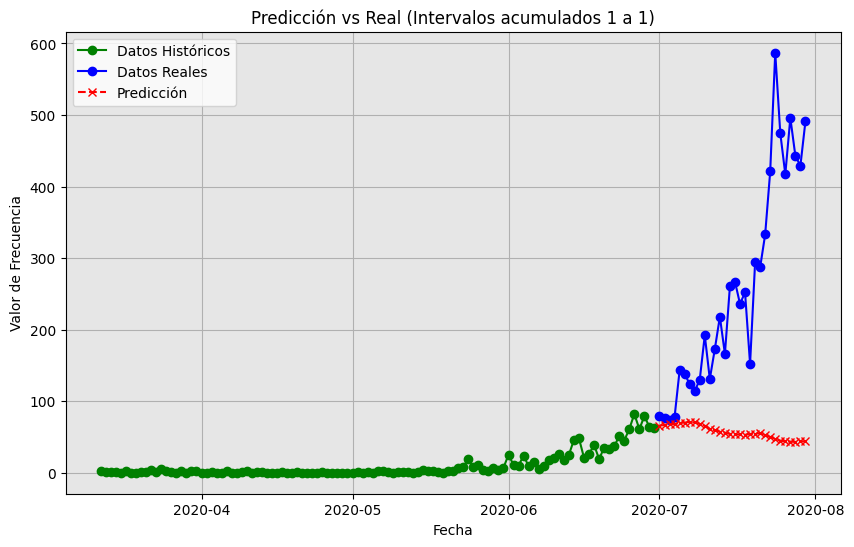

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 2: MAE = 187.61, MSE = 54042.86


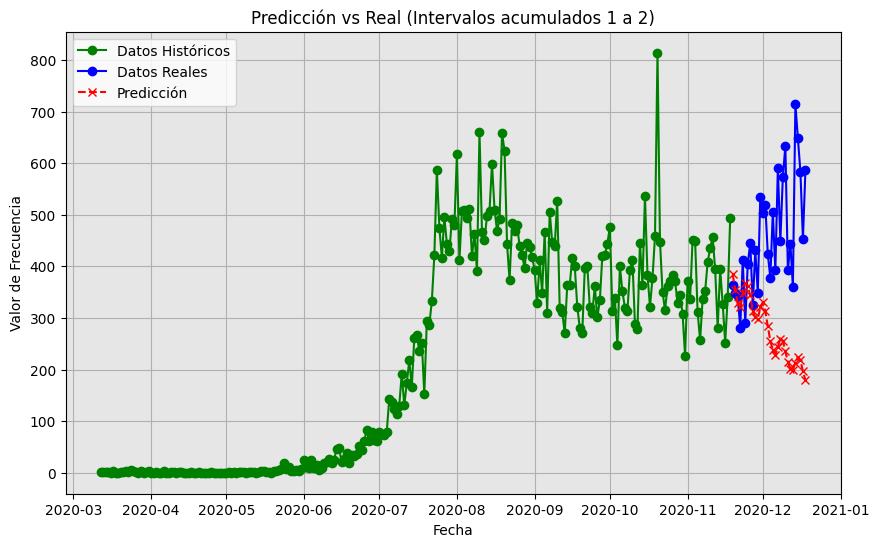

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 3: MAE = 316.34, MSE = 172432.14


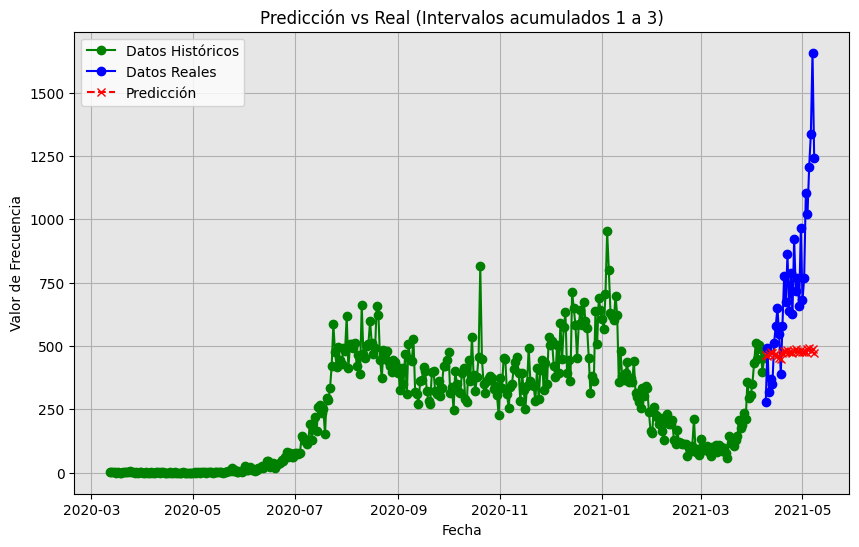

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 4: MAE = 41.80, MSE = 2038.77


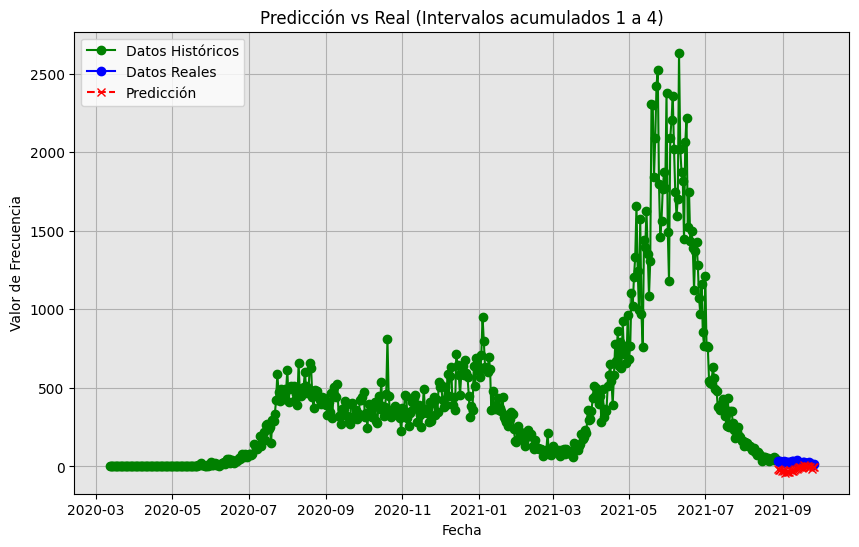

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 5: MAE = 385.63, MSE = 165428.20


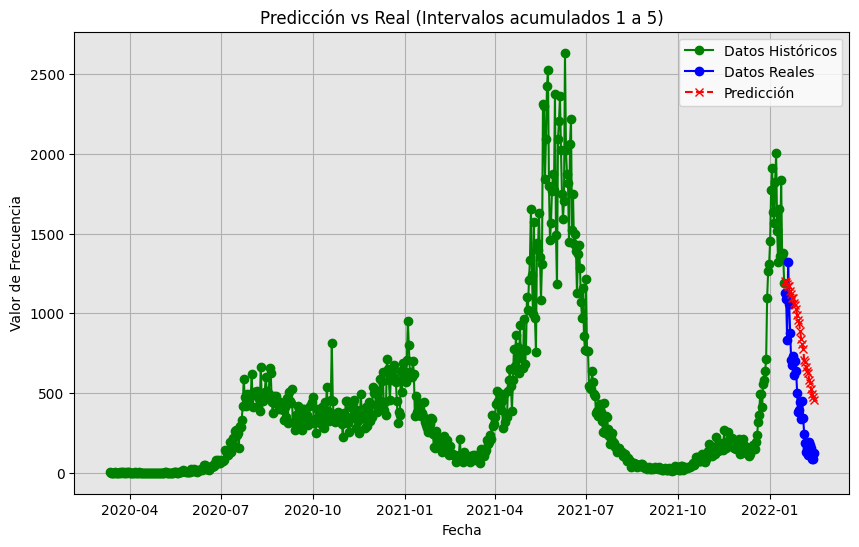

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 6: MAE = 151.10, MSE = 23289.37


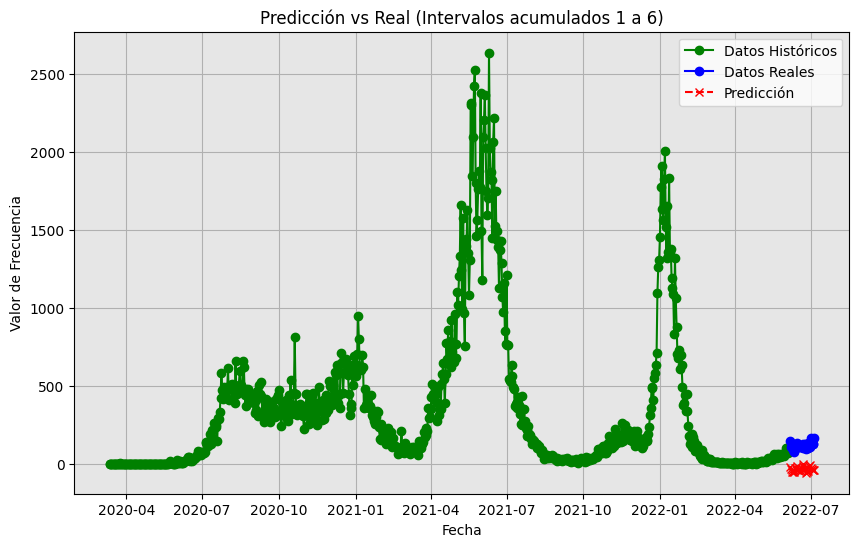

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 7: MAE = 416.36, MSE = 263496.67


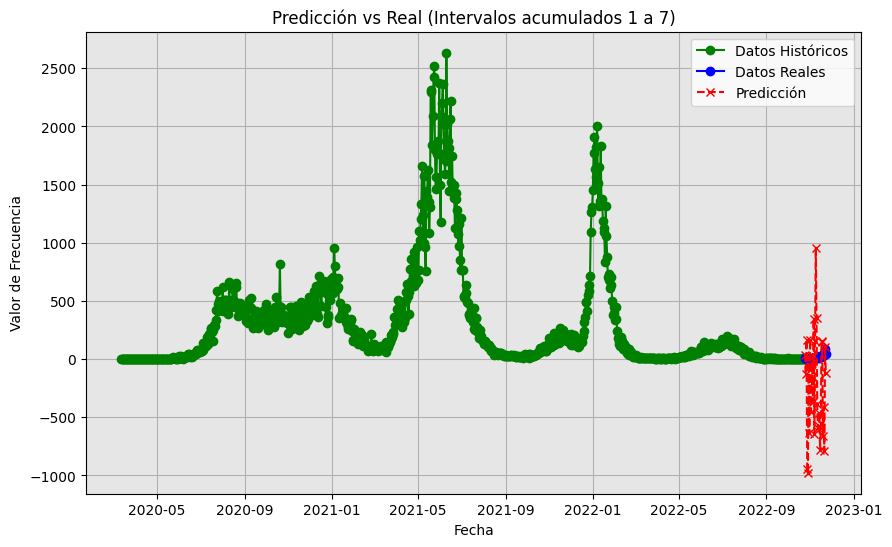

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 8: MAE = 61.51, MSE = 3840.70


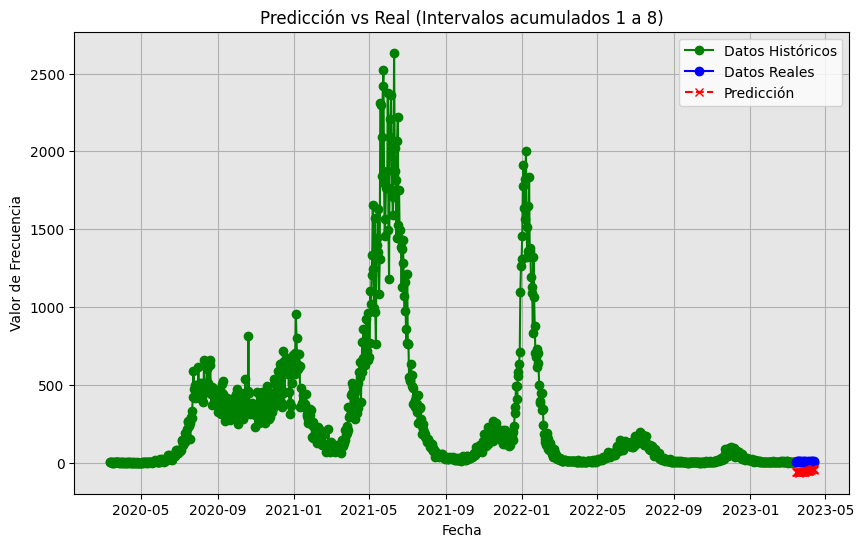


Resumen de métricas:
  Intervalos Acumulados         MAE            MSE       SMAPE
0      Intervalos 1 a 1  198.982635   63915.790876  106.295114
1      Intervalos 1 a 2  187.611755   54042.863092   49.261507
2      Intervalos 1 a 3  316.336490  172432.138545   45.571056
3      Intervalos 1 a 4   41.801022    2038.773090  194.287409
4      Intervalos 1 a 5  385.632291  165428.200357   73.704114
5      Intervalos 1 a 6  151.101156   23289.372383  199.846611
6      Intervalos 1 a 7  416.363839  263496.665838  182.115716
7      Intervalos 1 a 8   61.508628    3840.695782  200.000000


In [ ]:
# Parameters
HORIZONTE = 30


resultados = []

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend="gpu",
        per_core_batch_size=32,
        horizon_len=HORIZONTE,
        num_layers=50
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        version='torch',
        huggingface_repo_id="google/timesfm-2.0-500m-pytorch"),
)

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]

    df_final = df[df['Intervalo'].isin(intervalos_incluir)]
    
    series = df_final['Frecuencia'].values.reshape(-1, 1)

    # Inicializamos el escalador y escalamos la serie
    scaler = MinMaxScaler(feature_range=(0, 1))
    series_scaled = scaler.fit_transform(series)

    # Convertimos la serie escalada en un DataFrame
    df_scaled = pd.DataFrame(series_scaled, columns=['Frecuencia'])

    # Concatenamos la columna 'Fecha' con la columna escalada
    df_concatenado = pd.concat([df_final[['Fecha']].reset_index(drop=True), df_scaled], axis=1)

    df_train = df_concatenado.iloc[:-HORIZONTE].copy()
    df_test = df_concatenado.iloc[-HORIZONTE:].copy()

    # df_train = df_final.iloc[:-HORIZONTE].copy()
    # df_test = df_final.iloc[-HORIZONTE:].copy()

    # Preparing the data for training

    data_hist = df_train[['Fecha', 'Frecuencia']].rename(columns={
        'Fecha': 'ds',
        'Frecuencia': 'sales'
    })
    data_hist["unique_id"] = "series_1"

    forecast_df = tfm.forecast_on_df(
        inputs=data_hist,
        freq='D',
        forecast_context_len= len(data_hist),
        value_name='sales',
        num_jobs=-1)
    
    # 6. Alinear fechas y calcular métricas

    y_true = df_test['Frecuencia']
    y_pred = forecast_df['timesfm']
    
    y_pred = scaler.inverse_transform(y_pred.values.reshape(-1, 1))
    y_true = scaler.inverse_transform(y_true.values.reshape(-1, 1))


    # Calculamos las métricas
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    smape_value = smape(y_true, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos históricos, datos reales (test) y predicción sobre el intervalo completo
    fig, ax = plt.subplots(figsize=(10, 6))
    # Cambiar el color de fondo del eje a un gris suave
    ax.set_facecolor('#e6e6e6')  # Puedes ajustar el código hexadecimal para obtener el gris deseado

    # Graficar datos históricos (entrenamiento)
    # Aquí se vuelven a invertir las escalas para graficar los valores reales
    historico = scaler.inverse_transform(df_train['Frecuencia'].values.reshape(-1, 1))
    ax.plot(df_train['Fecha'], historico, label="Datos Históricos", marker='o', color='green')

    # Graficar datos reales del test (último intervalo)
    ax.plot(df_test['Fecha'], y_true, label="Datos Reales", marker='o', color='blue')

    # Graficar la predicción
    ax.plot(df_test['Fecha'], y_pred, label="Predicción", marker='x', linestyle='--', color='red')

    # Etiquetas y detalles de la gráfica
    ax.set_title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Valor de Frecuencia")
    ax.legend()
    ax.grid(True)

    plt.show()



df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 

df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_2/timesfm_30.csv', index=False)